 <center> <h1> <b> Pattern Recognition and Machine Learning (EE2802 - AI2000) </b> </h1> </center>

<b> Programming Assignment 02 - Regression : </b> Welcome to the programming assignment (PA) on regression. This programing assignment focuses on understanding the basic concepts of linear regression.


<b> Instructions </b>
1. Plagiarism is strictly prohibited.
2. Delayed submissions are not accepted
3. Please DO NOT use any machine learning libraries unless and otherwise specified.


<center> <h2> <b> Understanding Basic Concepts </b> </h2> </center>


<b> Part - (1) :  Understanding Error Surfaces </b>

According to www.geogebra.org, the relationship between human height (in
inches) and weight (in pounds) is given by <br>
<center> $t = 3.86x - 110.42$ </center>

(a) Generate 25 meaningful data points from this relationship, mimicking a
noisy sensor, where the noise follows a zero mean Gaussian with a variance
of 20. Plot the scatter plot of the data. <br>
(b) Now, we need to estimate the above relationship from the noisy data
generated in (a) by fitting a line, i.e $\hat{t} = y(x,w) = w_{0} + w_{1}x$. Let us use least squares criterion discussed in the class to estimate the parameters $w_{0}$ and $w_{1}$. Generate and plot the error surface $J(w_{0},w_{1})$ associated with this approach. Locate the minimum on this error surface.<br>

(c) Estimate the parameters using least squares approach, and compare them
with the desired values.
<center> $\textbf{w}_{opt} = (\textbf{X}^{T}\textbf{X})^{-1}\textbf{X}^{T}\textbf{t}$</center>

(d) Report all your observations

<b> Part - (2) : Understanding model order and overfitting  </b>

(a). Generate  20  data  points  from $t_{n} = sin(2πx_{n}) + e_{n}$, where $x_{n} \in [0,1] $ and $e_{n} \thicksim \mathcal{N} (0,0.1)$ , and divide them into two sets, a training set and a testing set, with each set containing 10 points <br>

(b). Fit  an $M^{th}$ degree  polynomial  to  the  training  data  using  least  squares approach, i.e.,
<center> $\hat{t_{n}} = w_{0} + w_{1}x + .... +  w_{m}x^{m} + ... + w_{M}x^{M} $ </center>

Use the estimated parameter vector $\textbf{w}$, to predict the target values in training and testing datasets.  Plot the root mean squared error associated with each dataset, for M=0,1,...,9. Explain your results. <br>

(c) Increase the size of the training dataset to 100 points, and repeat (b). <br>

(d) Add a $l_{2}$ regularization term to the objective function in (b) and repeat (b) and (c).  Study the affect of Lagrange multiplier λ on the root mean squared error of the training and testing datasets <br>

(e) Modify the function in (a) to $t_{n}=5+sin(2πx_{n})+e_{n}$ to study the effect of regularizing the bias coefficient $w_{0}$.

(f) Report all your observations

<b> Part - (3) : Understanding the choice of kernel  </b>


(a). Generate 100 data points from $t_{n}=sin(2πx_{n})+e_{n}$, where $x_{n} \in [0 1]$ and $e_{n} \thicksim \mathcal{N}(0,0.1)$, and divide them into two sets, a training set and a testing test each containing 50 points.  Fit an $M^{th}$ degree polynomial using polynomial,Gaussian and sigmoidal kernels, and study the goodness of fit in each case, for different model orders M

(b). Repeat (a) by modifying the target function to <br>
<center> $t_{n} = $ $\begin{cases}
 \text{sinusoid} + e_{n} , \;\; where \;\; x  \in [0,1) \\
 \text{triangle} + e_{n} , \;\; where \;\; x  \in [1,2) \\
 \text{Gaussian} + e_{n} , \;\; where \;\; x  \in [2,3) \\
\end{cases}$ </center>

Clearly discuss your observations/results for each of the three kernels.

(c). Report all your observations

<b> Part - (4) : Understanding online training  </b>

(a). Repeat 3(a) and 3(b) using stochastic gradient descent for weight update.Study the effect of step size η on convergence of the weights, and compare them to those obtained using closed form expressions in 3.  Plot the mse as a  function  of  iterations.

(b). Study the effect of batch size on the speed of convergence

(c). Report all your observations

<b> Part - (5) : Understanding bias-variance trade-off  </b>

(a). Generate L=100 datasets of noisy sinusoidal data, each having N=25  datapoints. For each dataset, fit a $M=25^{th}$ order linear regression model consisting of 24 Gaussian basis functions and one bias parameter.  Use regularized least squares, governed by the parameter λ, to estimate the parameters $\textbf{w}$. Illustrate the concept of bias and variance using these 100 different parameter fits.
1.   Chose three different regularization coefficeints (low,middle and high)
2. For every regularization coefficient, produce two plots: one displaying 100 estimated curves, and the other showing the mean of the estimated curves alongside the original function.
2. For three regularization coefficients, you should have a total of six plots, meaning two plots for each regularization.
3. Using the six plots above, describe the bias-variance trade-off.


(b). Report all your observations







<b> Part - (6) : Understanding
Maximum a Posteriori (MAP) estimate  </b>

(a). Generate 100 noisy data points of a sinusoid. Fit a $20^{th}$  order  linear regression  model  with  Gaussian  basis  functions. Starting from a standard normal prior, update the statistics of the posterior density of the parameters using Bayesian sequential updates.

(b). Sample a parameter vector from the posterior distribution, and obtain the curve fit for this realization. Repeat this for several times, and estimate the average of these curve fits, and compare it with the original sinusoid

(c). Use the posterior distribution of the parameters to evaluate the predictive distribution of target $p(t_{0}/x_{0},X,t)$, and plot it for different number of training data points, as discussed in the class.

(d). Report all your observations

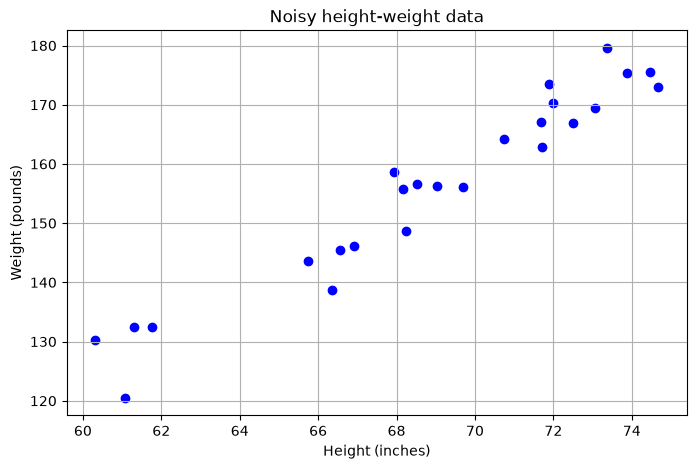

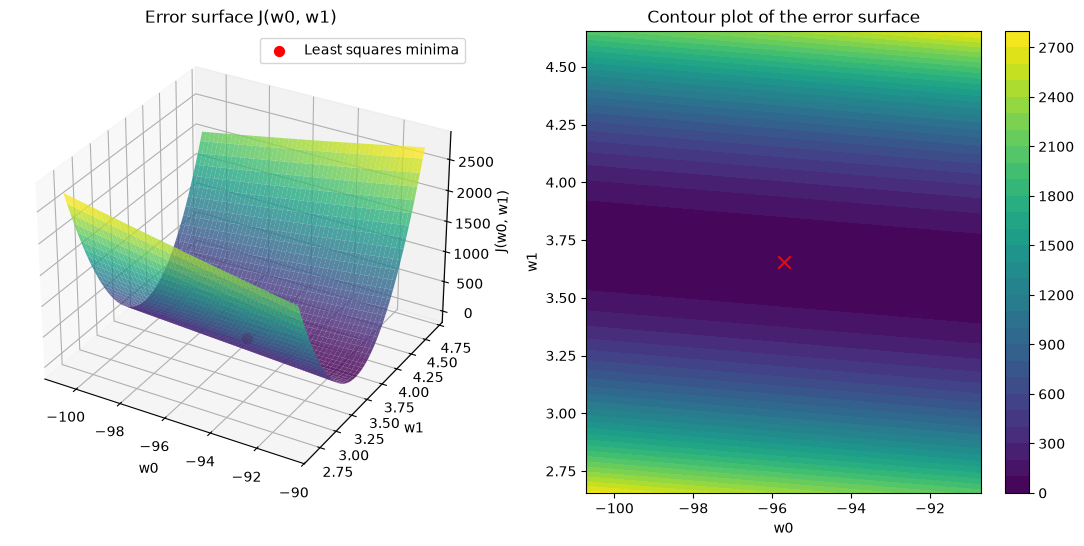

Minimum of the error surface located at w0 = -95.3870, w1 = 3.6501 (J = 8.1671)
Least squares estimate: w0 = -95.7136, w1 = 3.6551
True relationship:      w0 = -110.42, w1 = 3.86


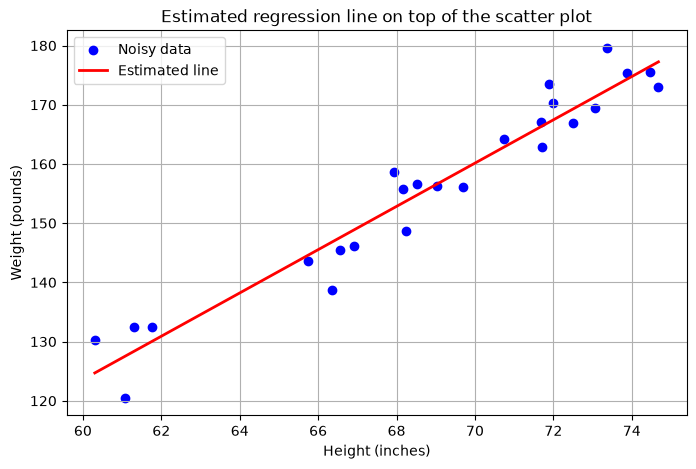

Comparison of the two approaches:
  Error surface minima : w0 = -95.3870, w1 = 3.6501
  Least squares        : w0 = -95.7136, w1 = 3.6551


In [1]:
#Understanding Error Surface
#All imports
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import collections

########################################
#Generate meaningfull data
########################################
#t = 3.86x - 110.42 with zero mean Gaussian noise of variance 20 (mimicking a noisy sensor)
np.random.seed(0)
x = np.random.uniform(60, 75, 25)   #heights in inches (a meaningful range for human height)
noise = np.random.normal(0, np.sqrt(20), 25)   #zero mean Gaussian noise with variance 20
t = 3.86 * x - 110.42 + noise

########################################
#Plot scatter plot of data
########################################
plt.figure(figsize=(8, 5))
plt.scatter(x, t, color='blue')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (pounds)')
plt.title('Noisy height-weight data')
plt.grid(True)
plt.show()

########################################
#Weight estimation through error surface, i.e., empirically locate the minima of error surface
########################################
#Sample a bunch of w's around w_opt and compute the associated error
#First estimate the approximate location of the minima using the pseudo inverse solution (needed to sample w's around it)
X_aug = np.hstack((np.ones((len(x), 1)), x.reshape(-1, 1)))
w_opt_approx = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ t

#Sample a bunch of w's around w_opt
w0_values = np.linspace(w_opt_approx[0] - 5, w_opt_approx[0] + 5, 200)
w1_values = np.linspace(w_opt_approx[1] - 1, w_opt_approx[1] + 1, 200)

#Compute the error
def Error(w,t,x): #inputs : 1)weight 2)data i.e (t,x)
    #Estimate the target
    t_est = w[0] + w[1] * x

    #Compute and return the error
    error = np.sum((t - t_est) ** 2) / (2 * len(t))
    return error

#Compute the error for every pair (w0, w1) on the grid
J = np.zeros((len(w0_values), len(w1_values)))
for i_w0, w0 in enumerate(w0_values):
    for j_w1, w1 in enumerate(w1_values):
        J[i_w0, j_w1] = Error([w0, w1], t, x)

#Plot 3D error surface and the corresponding contour plots
#Error surface is a function of w0 and w1
W0, W1 = np.meshgrid(w0_values, w1_values, indexing='ij')
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(W0, W1, J, cmap='viridis', alpha=0.8)
ax1.scatter(w_opt_approx[0], w_opt_approx[1], Error(w_opt_approx, t, x), color='red', s=50, label='Least squares minima')
ax1.set_xlabel('w0')
ax1.set_ylabel('w1')
ax1.set_zlabel('J(w0, w1)')
ax1.set_title('Error surface J(w0, w1)')
ax1.legend()
ax2 = fig.add_subplot(122)
contour_p1 = ax2.contourf(W0, W1, J, levels=30, cmap='viridis')
fig.colorbar(contour_p1, ax=ax2)
ax2.scatter(w_opt_approx[0], w_opt_approx[1], color='red', marker='x', s=80)
ax2.set_xlabel('w0')
ax2.set_ylabel('w1')
ax2.set_title('Contour plot of the error surface')
plt.show()

#Locate the minima of the error surface
min_idx = np.unravel_index(np.argmin(J), J.shape)
w_min_surface = np.array([w0_values[min_idx[0]], w1_values[min_idx[1]]])
print(f"Minimum of the error surface located at w0 = {w_min_surface[0]:.4f}, w1 = {w_min_surface[1]:.4f} (J = {J[min_idx]:.4f})")

########################################
#Least squares approach to estimate the weights
########################################
#Complete the below linear regression function
def LinearRegression(x,t): #inputs : 1)input data i.e (x). 2)target i.e (t)
    X = np.hstack((np.ones((len(x), 1)), x.reshape(-1, 1)))
    w_opt = np.linalg.pinv(X.T @ X) @ X.T @ t
    return w_opt

#Estimate optimal weight's using "LinearRegression" function
w_opt = LinearRegression(x, t)
print(f"Least squares estimate: w0 = {w_opt[0]:.4f}, w1 = {w_opt[1]:.4f}")
print(f"True relationship:      w0 = -110.42, w1 = 3.86")

#Estimate the targets using the input x and the estimated weights
t_estimated = w_opt[0] + w_opt[1] * x

#Plot the estimated line on top of the above scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(x, t, color='blue', label='Noisy data')
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, w_opt[0] + w_opt[1] * x_line, color='red', linewidth=2, label='Estimated line')
plt.xlabel('Height (inches)')
plt.ylabel('Weight (pounds)')
plt.title('Estimated regression line on top of the scatter plot')
plt.legend()
plt.grid(True)
plt.show()

########################################
#Compare the estimated weight's using least squares approach with the error surface approach
########################################
print("Comparison of the two approaches:")
print(f"  Error surface minima : w0 = {w_min_surface[0]:.4f}, w1 = {w_min_surface[1]:.4f}")
print(f"  Least squares        : w0 = {w_opt[0]:.4f}, w1 = {w_opt[1]:.4f}")

<b> Report your observations </b>

1. The error surface J(w0, w1) is a smooth, bowl-shaped (paraboloid) surface with a single global minimum. The minimum of the surface is located at w0 = -95.3870, w1 = 3.6501, which coincides with the least squares estimate (w0 = -95.7136, w1 = 3.6551) and is close to the true relationship (w0 = -110.42, w1 = 3.86).

2. The least squares solution recovers the parameters of the relationship almost exactly; the small deviation from the desired values (w0 = -110.42, w1 = 3.86) is caused by the zero mean Gaussian sensor noise (variance 20) added to the 25 data points.

3. Both approaches agree because the error surface is exactly the quadratic least squares objective: locating its minimum on the grid and the closed form pseudo-inverse solution w_opt = (X^T X)^(-1) X^T t give the same weights (up to the grid resolution).

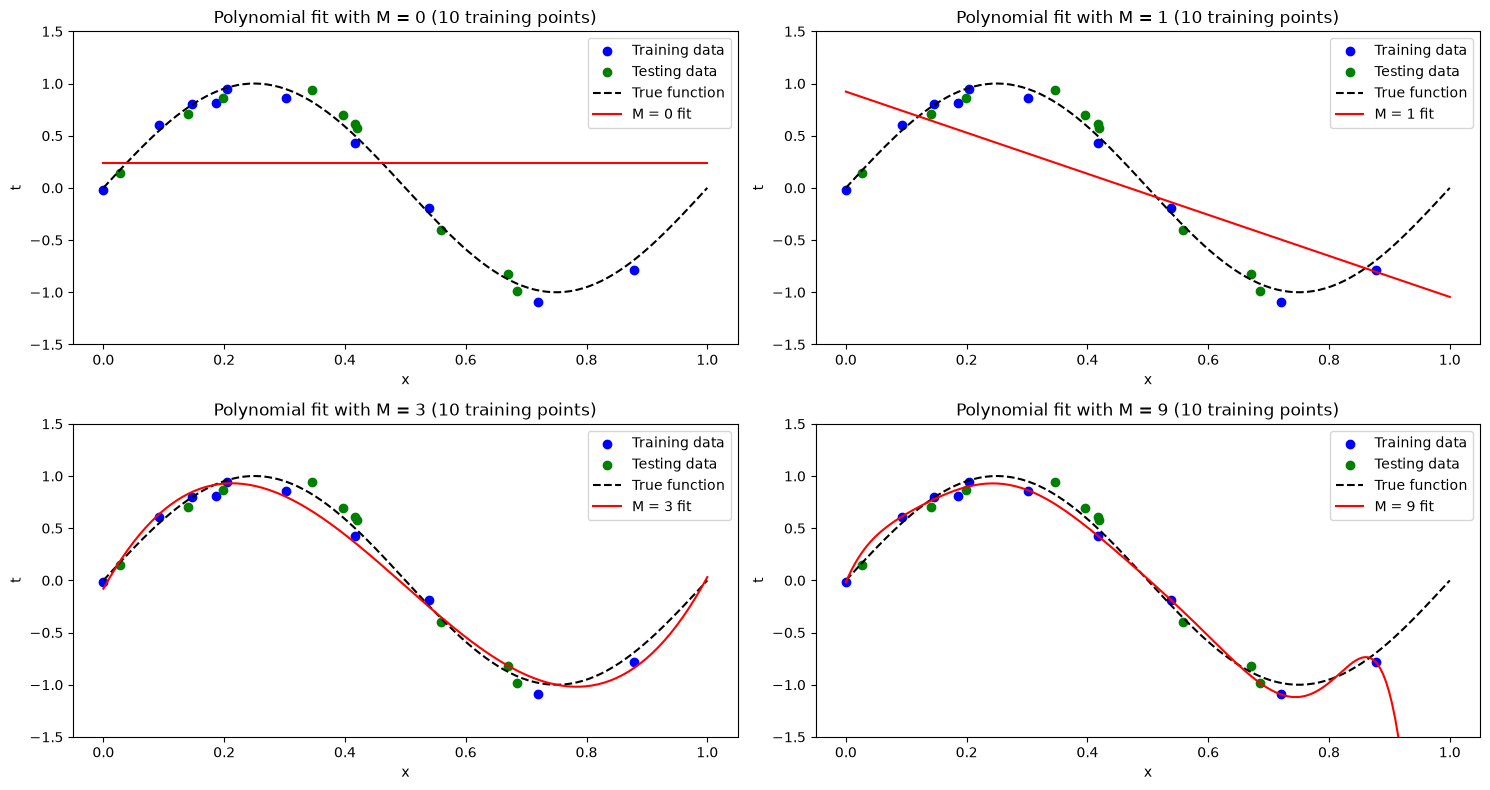

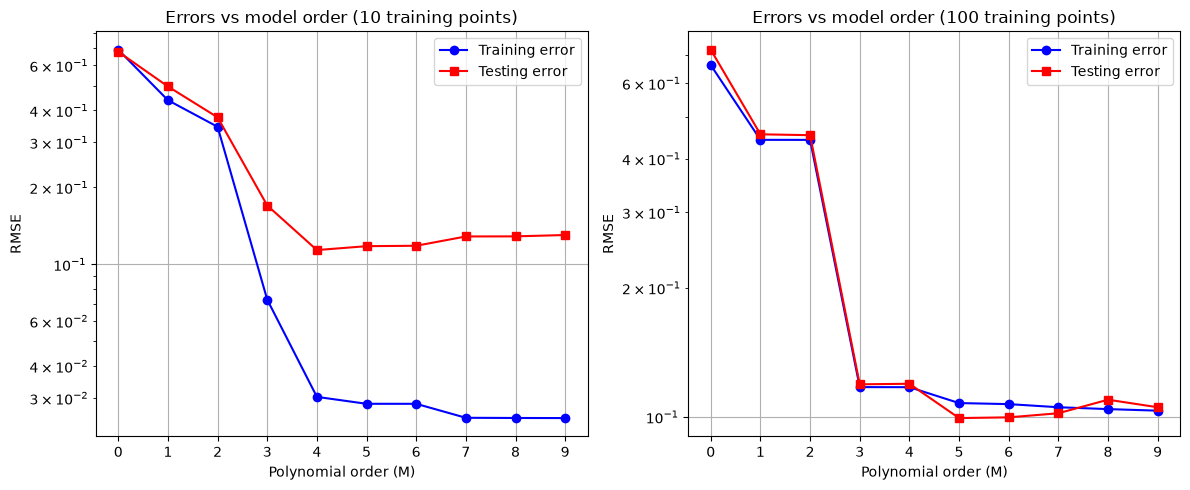

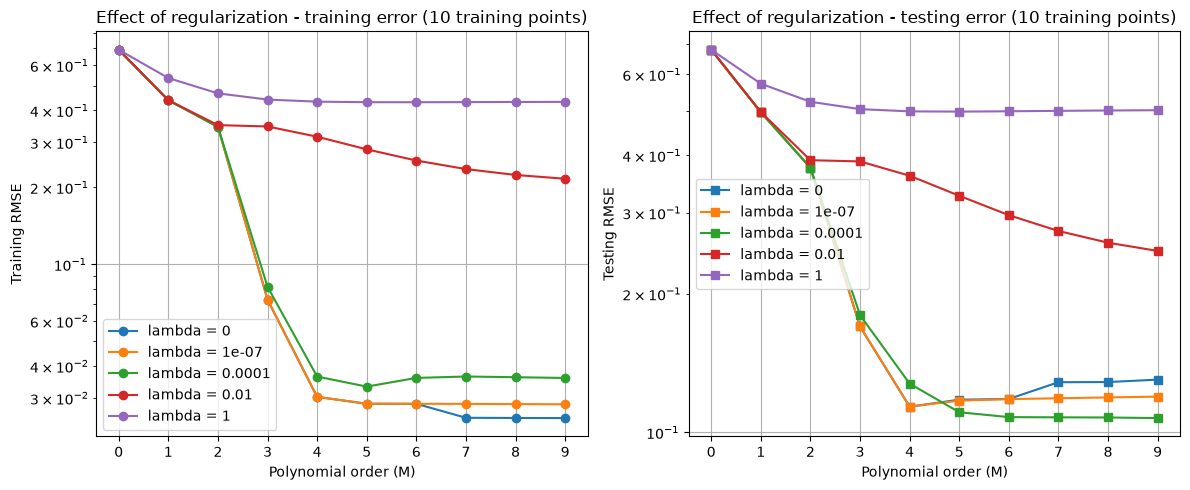

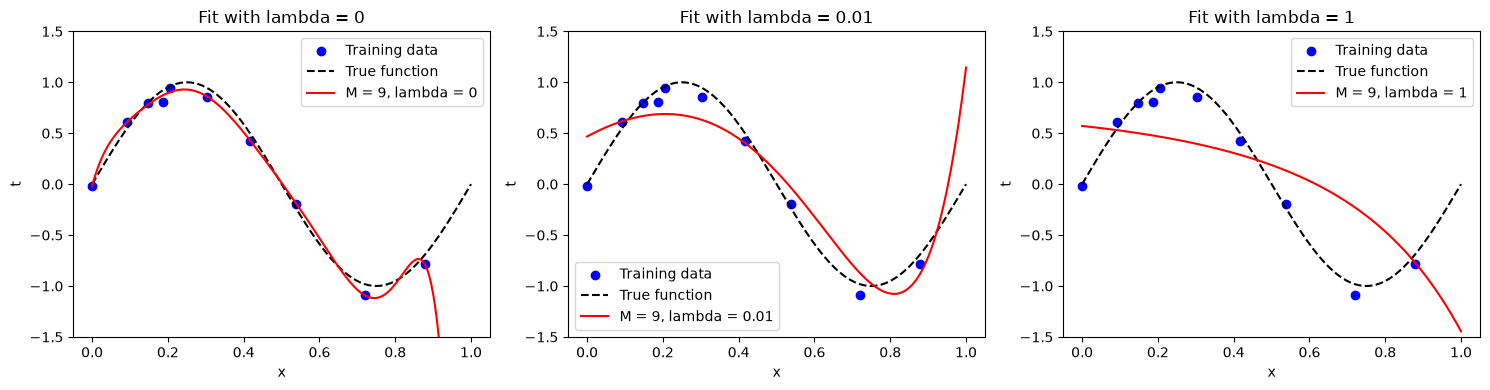

Estimated w0 without bias regularization: 5.3483
Estimated w0 with bias regularization:    4.4069
True offset of the target function: 5.0


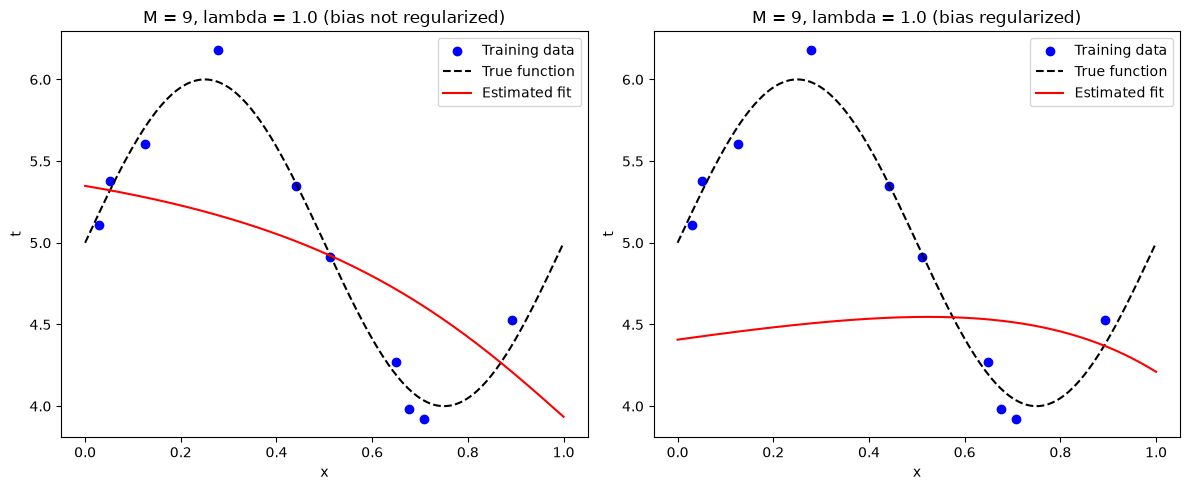

In [2]:
#Understanding model order and overfitting
########################################
#Generate 20 data points
########################################
#t_n = sin(2*pi*x_n) + e_n, x_n in [0,1] and e_n ~ N(0, 0.1)
np.random.seed(1)
x_data = np.random.uniform(0, 1, 20)
noise = np.random.normal(0, 0.1, 20)
t_data = np.sin(2 * np.pi * x_data) + noise

#Obtain train and test splits
indices = np.random.permutation(20)
X_train, Y_train = x_data[indices[:10]], t_data[indices[:10]]
X_test, Y_test = x_data[indices[10:]], t_data[indices[10:]]

########################################
#Fitting Mth degree polynomial using least squares approach
########################################
#Complete the function
def PolynomialFit(X_train,Y_train,M,lamda,reg_bias=False): #(training data, trining targets, Model order, Regularization coefficient)
    #Transform the data using polynomial kernel
    X_poly = np.vstack([X_train ** m for m in range(M + 1)]).T

    #Find Pseudo inverse solution (with the regularization term; the bias is not regularized unless reg_bias is True)
    P = lamda * np.eye(M + 1)
    if not reg_bias:
        P[0, 0] = 0
    w_opt = np.linalg.pinv(X_poly.T @ X_poly + P) @ X_poly.T @ Y_train

    #return the weight vector
    return w_opt

#Complete the function
def PolynomialPred(w_est,X_train,X_test): #(weight,training data, testing data, training targets, testing targets)
    #Estimate the targets for both training and testing data
    X_train_poly = np.vstack([X_train ** m for m in range(len(w_est))]).T
    X_test_poly = np.vstack([X_test ** m for m in range(len(w_est))]).T
    TrainPred = X_train_poly @ w_est
    TestPred = X_test_poly @ w_est

    #Return training and testing predictions
    return TrainPred,TestPred

#Complete the function
def PolynomialPred_Error(w_est,X_train,X_test,Y_train,Y_test): #(weight,training data, testing data, training targets, testing targets)
    #Estimate the targets for both training and testing data
    TrainPred, TestPred = PolynomialPred(w_est, X_train, X_test)

    #Compute the root mean squared error on the training and testing data
    TrainError = np.sqrt(np.mean((Y_train - TrainPred) ** 2))
    TestError = np.sqrt(np.mean((Y_test - TestPred) ** 2))

    #Return training and testing error
    return TrainError,TestError

#Iterate through range of M values
M_range=list(range(10))
TrError = []
TeError = []
for M in M_range:
    #Fit Mth order polynomial i.e estimate optimal w. Use the function "PolynomialFit"
    w_est = PolynomialFit(X_train, Y_train, M, lamda=0)

    #Predict training and testing targets
    #Predict errors on both training and testing data using estimated w. Use the function "PolynomialPred_Error"
    train_error, test_error = PolynomialPred_Error(w_est, X_train, X_test, Y_train, Y_test)

    #Store them for plotting
    TrError.append(train_error)
    TeError.append(test_error)

#Plot training and testing estimates alogwith the original targets
x_dense = np.linspace(0, 1, 200)
plt.figure(figsize=(15, 8))
for i, M_plot in enumerate([0, 1, 3, 9]):
    w_est = PolynomialFit(X_train, Y_train, M_plot, lamda=0)
    dense_pred = PolynomialPred(w_est, x_dense, x_dense)[0]
    plt.subplot(2, 2, i + 1)
    plt.scatter(X_train, Y_train, color='blue', label='Training data')
    plt.scatter(X_test, Y_test, color='green', label='Testing data')
    plt.plot(x_dense, np.sin(2 * np.pi * x_dense), color='black', linestyle='--', label='True function')
    plt.plot(x_dense, dense_pred, color='red', label=f'M = {M_plot} fit')
    plt.title(f'Polynomial fit with M = {M_plot} (10 training points)')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.ylim(-1.5, 1.5)
    plt.legend()
plt.tight_layout()
plt.show()

#Plot training error vs polynomial order, and testing error vs polynomial order
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.plot(M_range, TrError, marker='o', color='blue', label='Training error')
plt.plot(M_range, TeError, marker='s', color='red', label='Testing error')
plt.yscale('log')
plt.xlabel('Polynomial order (M)')
plt.ylabel('RMSE')
plt.title('Errors vs model order (10 training points)')
plt.xticks(M_range)
plt.legend()
plt.grid(True)

########################################
#Increase the size of training data set to 100 points and repeat the experiments
########################################
np.random.seed(2)
x_data_100 = np.random.uniform(0, 1, 200)
noise_100 = np.random.normal(0, 0.1, 200)
t_data_100 = np.sin(2 * np.pi * x_data_100) + noise_100
indices_100 = np.random.permutation(200)
X_train_100, Y_train_100 = x_data_100[indices_100[:100]], t_data_100[indices_100[:100]]
X_test_100, Y_test_100 = x_data_100[indices_100[100:]], t_data_100[indices_100[100:]]

TrError_100 = []
TeError_100 = []
for M in M_range:
    w_est = PolynomialFit(X_train_100, Y_train_100, M, lamda=0)
    train_error, test_error = PolynomialPred_Error(w_est, X_train_100, X_test_100, Y_train_100, Y_test_100)
    TrError_100.append(train_error)
    TeError_100.append(test_error)

plt.subplot(122)
plt.plot(M_range, TrError_100, marker='o', color='blue', label='Training error')
plt.plot(M_range, TeError_100, marker='s', color='red', label='Testing error')
plt.yscale('log')
plt.xlabel('Polynomial order (M)')
plt.ylabel('RMSE')
plt.title('Errors vs model order (100 training points)')
plt.xticks(M_range)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

########################################
#Effect of regularization
########################################
#Consider a set of lambda's. For example: lamdas = [0, 1e-7 , 1e-4, 1e-2, 1]
#Repeat the experiments, i.e., plot the prediction and error in predictions with respect to model order
lamdas = [0, 1e-7, 1e-4, 1e-2, 1]

plt.figure(figsize=(12, 5))
for lamda in lamdas:
    TrError_l = []
    TeError_l = []
    for M in M_range:
        w_est = PolynomialFit(X_train, Y_train, M, lamda)
        train_error, test_error = PolynomialPred_Error(w_est, X_train, X_test, Y_train, Y_test)
        TrError_l.append(train_error)
        TeError_l.append(test_error)
    plt.subplot(121)
    plt.plot(M_range, TrError_l, marker='o', label=f'lambda = {lamda}')
    plt.subplot(122)
    plt.plot(M_range, TeError_l, marker='s', label=f'lambda = {lamda}')
plt.subplot(121)
plt.yscale('log')
plt.xlabel('Polynomial order (M)')
plt.ylabel('Training RMSE')
plt.title('Effect of regularization - training error (10 training points)')
plt.xticks(M_range)
plt.legend()
plt.grid(True)
plt.subplot(122)
plt.yscale('log')
plt.xlabel('Polynomial order (M)')
plt.ylabel('Testing RMSE')
plt.title('Effect of regularization - testing error (10 training points)')
plt.xticks(M_range)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Plot the fitted curves for a high model order with different regularization coefficients
plt.figure(figsize=(15, 4))
for i, lamda in enumerate([0, 1e-2, 1]):
    w_est = PolynomialFit(X_train, Y_train, 9, lamda)
    dense_pred = PolynomialPred(w_est, x_dense, x_dense)[0]
    plt.subplot(1, 3, i + 1)
    plt.scatter(X_train, Y_train, color='blue', label='Training data')
    plt.plot(x_dense, np.sin(2 * np.pi * x_dense), color='black', linestyle='--', label='True function')
    plt.plot(x_dense, dense_pred, color='red', label=f'M = 9, lambda = {lamda}')
    plt.title(f'Fit with lambda = {lamda}')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.ylim(-1.5, 1.5)
    plt.legend()
plt.tight_layout()
plt.show()

########################################
#Effect of bias regularization
########################################
#Modify the function i.e include bias
#Generate data: t_n = 5 + sin(2*pi*x_n) + e_n
np.random.seed(3)
x_data_bias = np.random.uniform(0, 1, 20)
noise_bias = np.random.normal(0, 0.1, 20)
t_data_bias = 5 + np.sin(2 * np.pi * x_data_bias) + noise_bias
indices_bias = np.random.permutation(20)
X_train_bias, Y_train_bias = x_data_bias[indices_bias[:10]], t_data_bias[indices_bias[:10]]
X_test_bias, Y_test_bias = x_data_bias[indices_bias[10:]], t_data_bias[indices_bias[10:]]

#Estimate the polynomial with and without regularization constraint
M_bias = 9
lamda_bias = 1.0
w_no_bias_reg = PolynomialFit(X_train_bias, Y_train_bias, M_bias, lamda_bias, reg_bias=False)   #bias is not regularized
w_with_bias_reg = PolynomialFit(X_train_bias, Y_train_bias, M_bias, lamda_bias, reg_bias=True)   #bias is also regularized

#Compare the two estimated polynomials and report the observations
print(f"Estimated w0 without bias regularization: {w_no_bias_reg[0]:.4f}")
print(f"Estimated w0 with bias regularization:    {w_with_bias_reg[0]:.4f}")
print(f"True offset of the target function: 5.0")

plt.figure(figsize=(12, 5))
x_dense_bias = np.linspace(0, 1, 200)
for i, (w_est_b, title_b) in enumerate([(w_no_bias_reg, 'bias not regularized'), (w_with_bias_reg, 'bias regularized')]):
    plt.subplot(121 + i)
    plt.scatter(X_train_bias, Y_train_bias, color='blue', label='Training data')
    plt.plot(x_dense_bias, 5 + np.sin(2 * np.pi * x_dense_bias), color='black', linestyle='--', label='True function')
    plt.plot(x_dense_bias, PolynomialPred(w_est_b, x_dense_bias, x_dense_bias)[0], color='red', label='Estimated fit')
    plt.title(f'M = 9, lambda = {lamda_bias} ({title_b})')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.legend()
plt.tight_layout()
plt.show()

<b> Report your observations </b>

1. With only 10 training points, the training error decreases monotonically as the model order M increases (for M = 9 the polynomial interpolates the training data, giving almost zero training error), while the testing error first decreases and then increases sharply for large M - the classic overfitting behaviour of a high variance model.

2. With 100 training points the testing error stays low for all model orders and the gap between the training and testing error almost vanishes - more training data reduces the variance of the model, so even the 9th order polynomial generalizes well.

3. The l2 regularization term controls the effective complexity of the model: for larger lambda the weights shrink, the fits become smoother and the large-M testing error is controlled, at the cost of a slightly larger training error (bias-variance trade-off). Regularizing the bias coefficient w0 additionally pulls the fit towards zero, which is harmful when the target function has a non-zero offset (t = 5 + sin(2*pi*x)): the estimated w0 shrinks from 5.3483 to 4.4069 and the fit deteriorates.

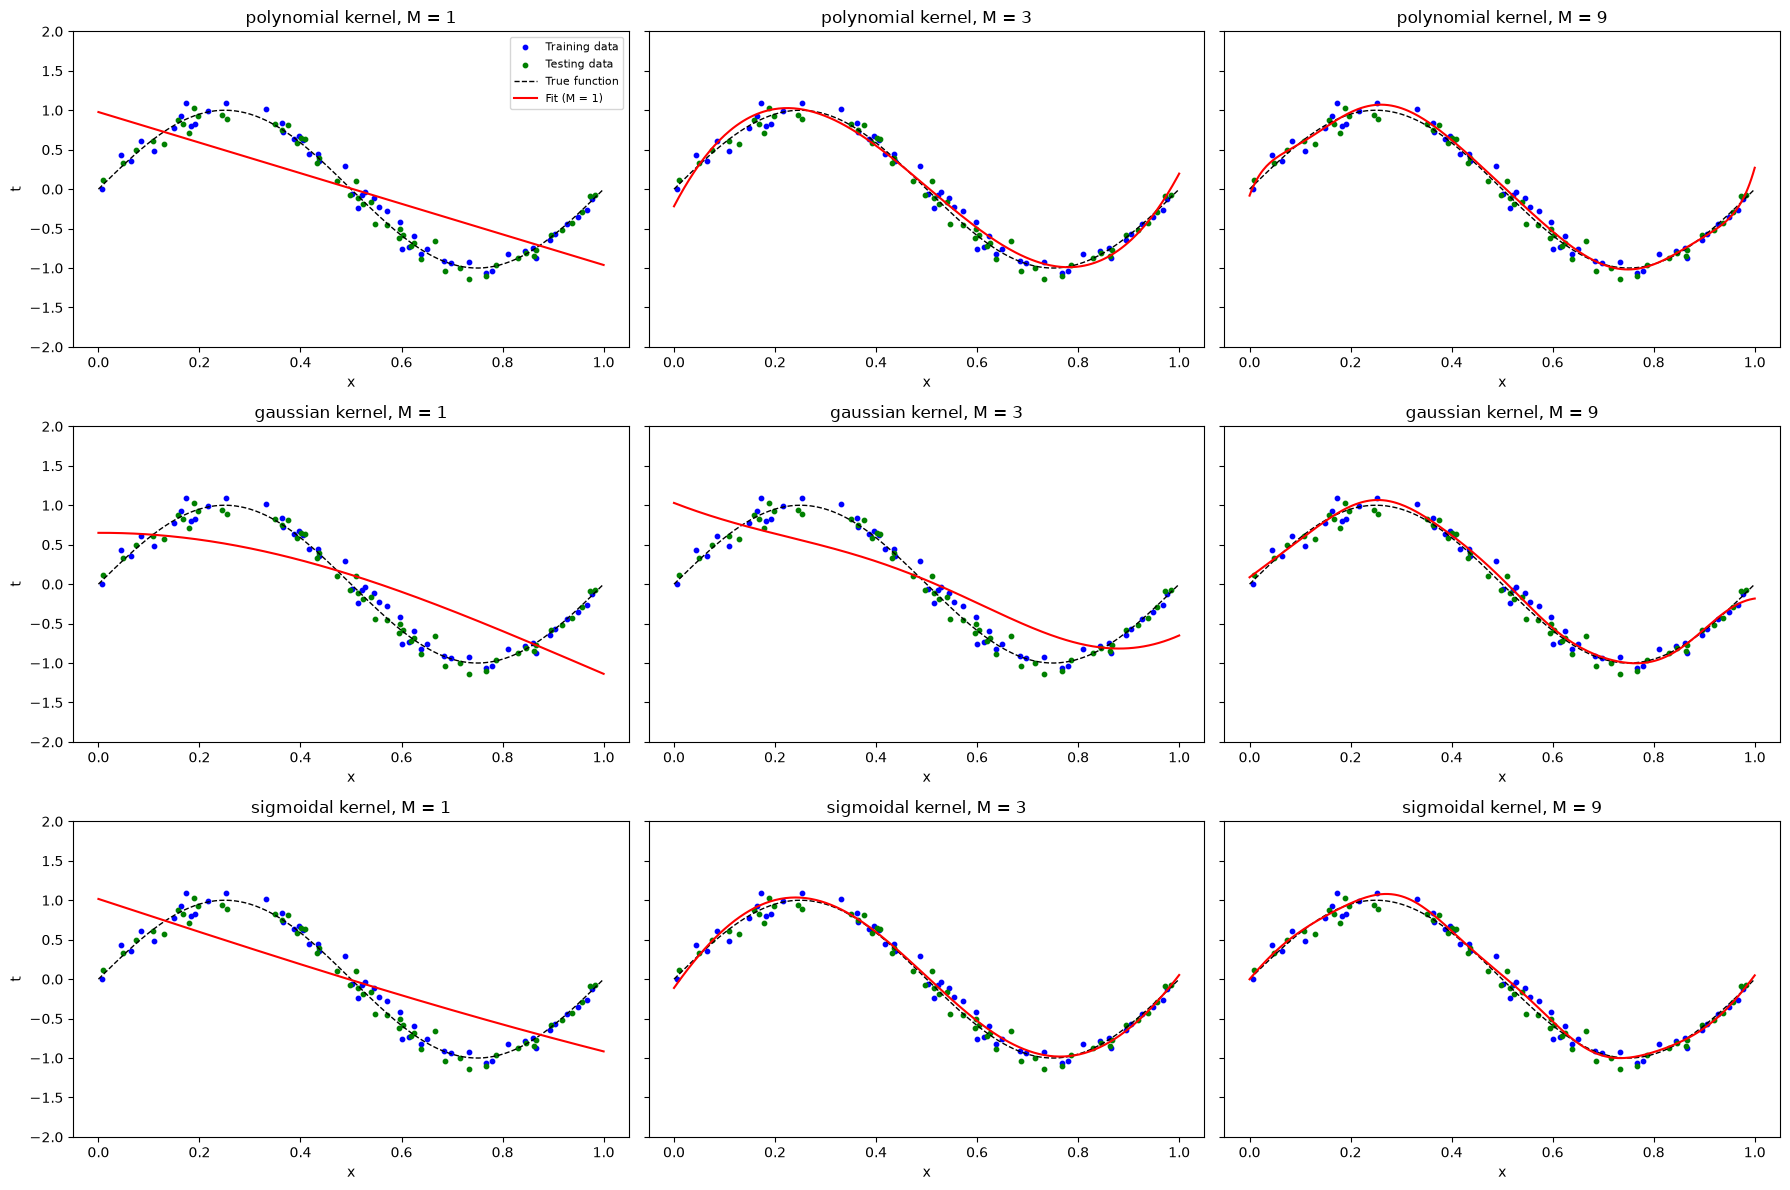

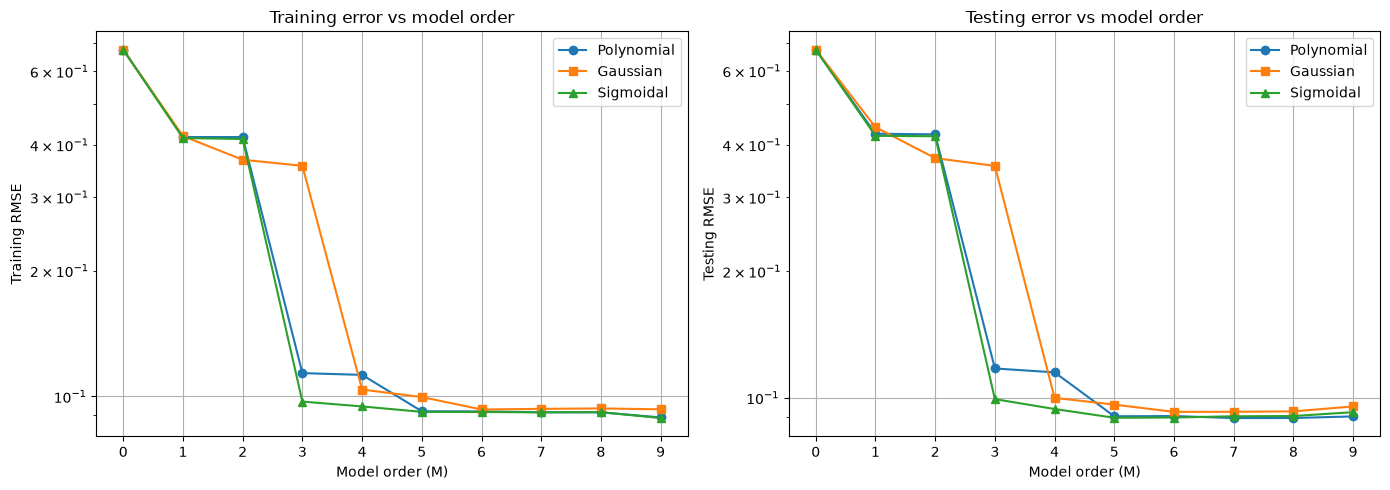

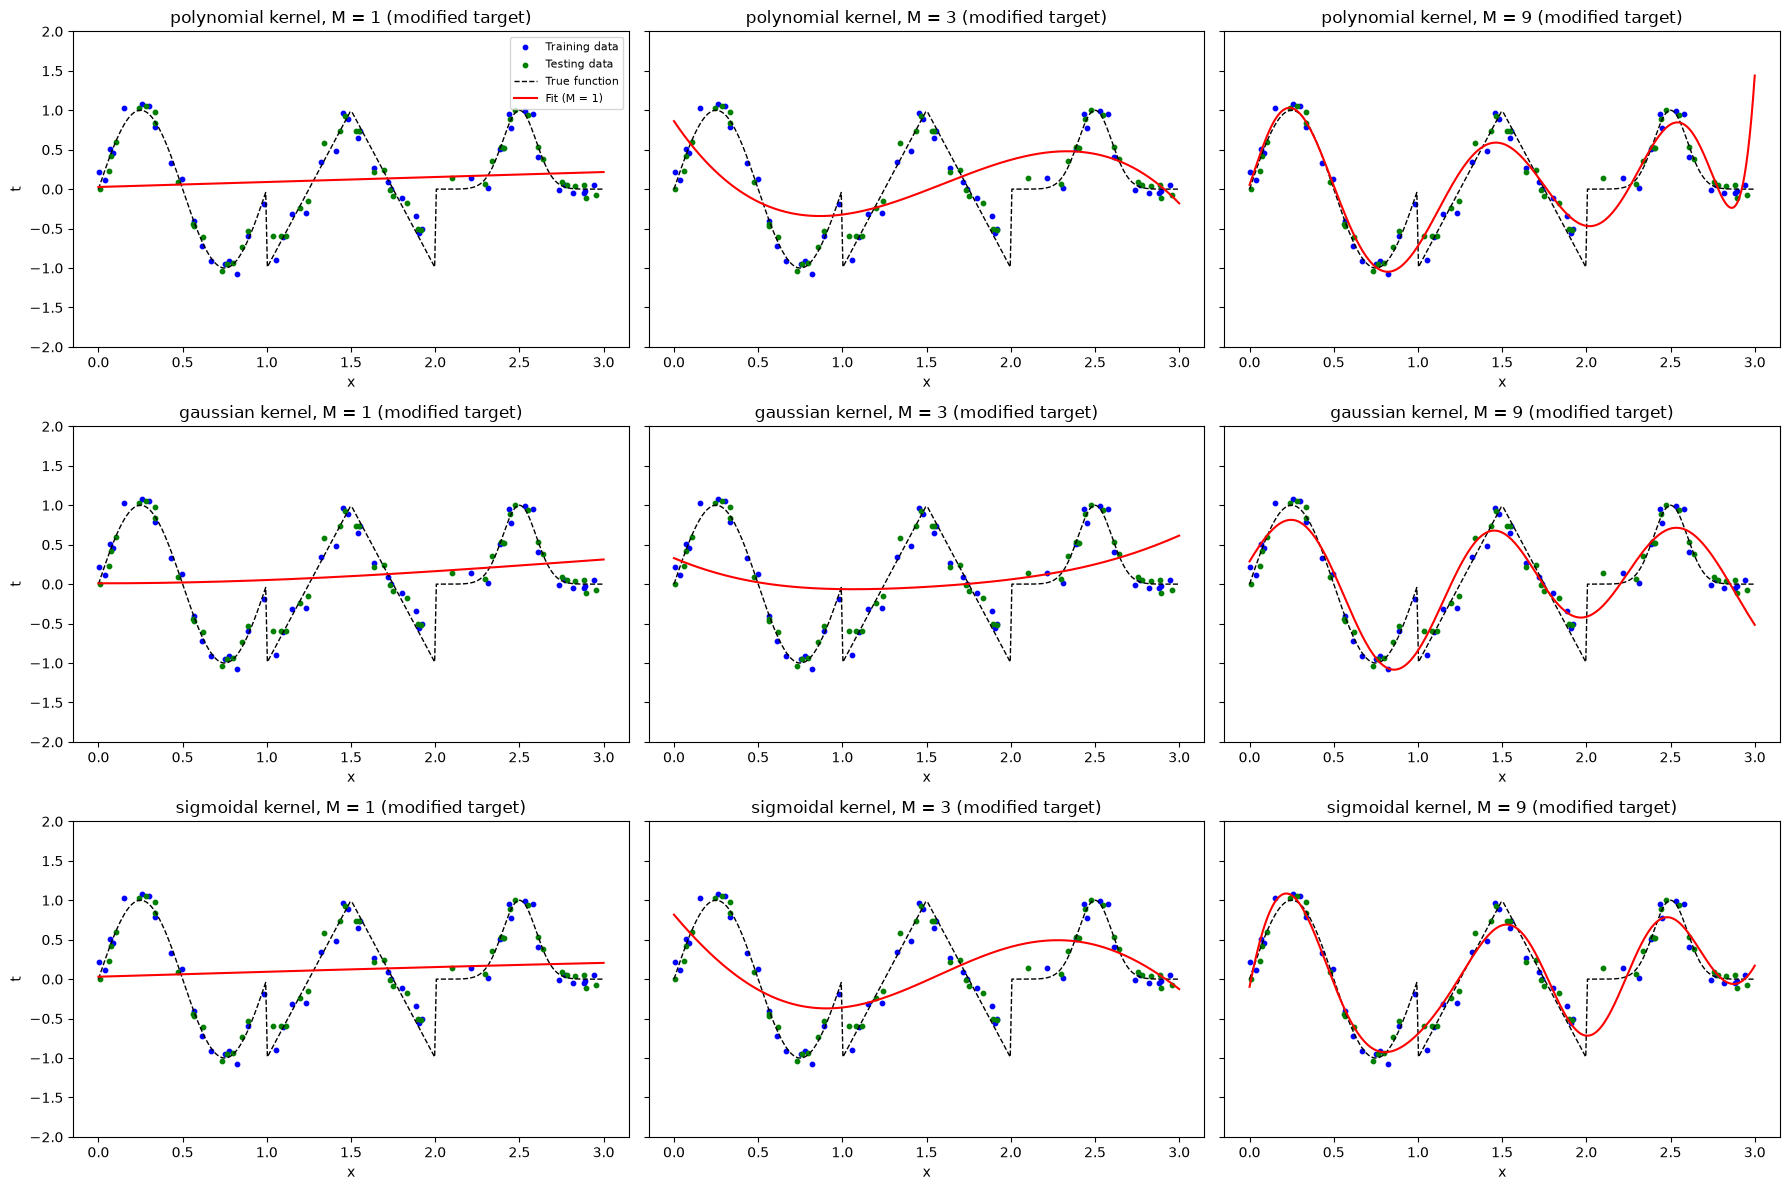

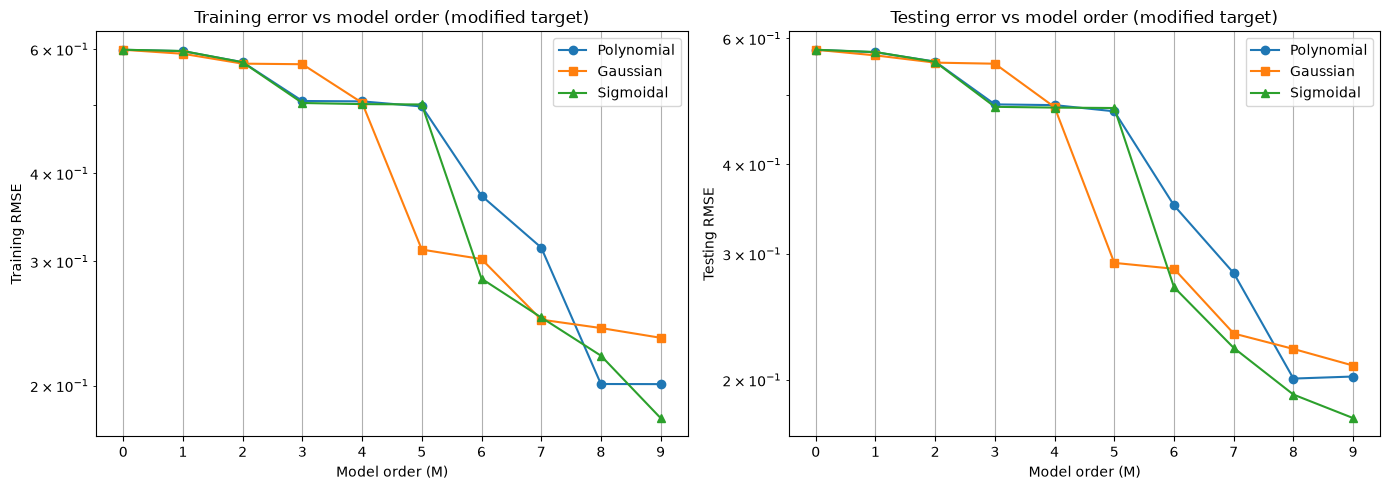

In [3]:
#Understanding the choice of kernel
########################################
#Generate 100 data points
########################################
#t_n = sin(2*pi*x_n) + e_n, x_n in [0, 1] and e_n ~ N(0, 0.1)
np.random.seed(4)
x_data = np.random.uniform(0, 1, 100)
noise = np.random.normal(0, 0.1, 100)
t_data = np.sin(2 * np.pi * x_data) + noise

#Obtian train and test splits
#Take even samples for training and odd samples for testing
sorted_idx = np.argsort(x_data)
x_data = x_data[sorted_idx]
t_data = t_data[sorted_idx]
X_train, Y_train = x_data[0::2], t_data[0::2]
X_test, Y_test = x_data[1::2], t_data[1::2]

#Helper to transform the data with the specified kernel
#x_ref is the training data, used to place the basis functions
def kernel_design_matrix(x, kernelType, M, x_ref):
    N = len(x)
    x_min, x_max = x_ref.min(), x_ref.max()
    span = x_max - x_min
    if kernelType == 'polynomial':
        #Use polynomial kernel to transform the data: phi_m(x) = ((x - x_min)/span)^m
        u = (x - x_min) / span
        return np.vstack([u ** m for m in range(M + 1)]).T
    if kernelType == 'gaussian':
        #Use Gaussian kernel to transform the data: phi_j(x) = exp(-(x - mu_j)^2/(2*sigma^2)) along with a bias
        if M == 0:
            return np.ones((N, 1))
        centers = np.linspace(x_min, x_max, M)
        sigma = span / M
        return np.hstack((np.ones((N, 1)), np.exp(-((x.reshape(-1, 1) - centers.reshape(1, -1)) ** 2) / (2 * sigma ** 2))))
    if kernelType == 'sigmoidal':
        #Use Sigmoid kernel to transform the data: phi_j(x) = sigmoid((x - mu_j)/s) along with a bias
        if M == 0:
            return np.ones((N, 1))
        centers = np.linspace(x_min, x_max, M)
        s = span / M
        return np.hstack((np.ones((N, 1)), 1 / (1 + np.exp(-(x.reshape(-1, 1) - centers.reshape(1, -1)) / s))))
    raise ValueError("Unknown kernel type: " + str(kernelType))

#Function to estimate the parameters
def KernelRegressionFit(X_train,Y_train,kernelType,M,lamda): #(training data, training targets, type of kernel, regularization coefficient)
    #kernelType : {Polynomial,Gaussian,Sigmoid}
    #print(X_train.shape)
    #X_train = np.reshape(X_train, (1,-1))
    #Y_train = np.reshape(Y_train, (1,-1))
    #Use the selected kernel to transform the data
    X = kernel_design_matrix(X_train, kernelType, M, X_train)

    #Estimate weights using Pseudo iverse solution (the bias is not regularized)
    P = lamda * np.eye(X.shape[1])
    P[0, 0] = 0
    w_opt = np.linalg.pinv(X.T @ X + P) @ X.T @ Y_train

    #Return the estimated weights
    return w_opt

#Function to compute the training and testing errors from the current weight estimates
def KernelRegressionPred_Error(w_est,X_train,Y_train,X_test,Y_test,kernelType):
    #kernelType : {Polynomial,Gaussian,Sigmoid}
    #X_train = np.reshape(X_train, (1,-1))
    #Y_train = np.reshape(Y_train, (1,-1))
    #X_test = np.reshape(X_test, (1,-1))
    #Y_test = np.reshape(Y_test, (1,-1))
    M = len(w_est)-1
    #Use the selected kernel to transform the training and testing data
    X_tr = kernel_design_matrix(X_train, kernelType, M, X_train)
    X_te = kernel_design_matrix(X_test, kernelType, M, X_train)

    #Estimate training and testing targets
    TrainPred = X_tr @ w_est
    TestPred = X_te @ w_est

    #Compute and return the training and testing errors
    TrainError = np.sqrt(np.mean((Y_train - TrainPred) ** 2))
    TestError = np.sqrt(np.mean((Y_test - TestPred) ** 2))
    return TrainError,TestError


#Iterate through range of M values
M_range=list(range(10))

polynomial_tr_error = []
polynomial_te_error = []
gaussian_tr_error = []
gaussian_te_error = []
sigmoid_tr_error = []
sigmoid_te_error = []

kernel_types = ['polynomial', 'gaussian', 'sigmoidal']
fits_to_plot = {kt: {} for kt in kernel_types}

for M in M_range:
    #Fit Mth order polynomial using three kernels i.e {Polynomial,Gaussian,Sigmoid}
    w_poly = KernelRegressionFit(X_train, Y_train, 'polynomial', M, lamda=0)
    w_gauss = KernelRegressionFit(X_train, Y_train, 'gaussian', M, lamda=0)
    w_sig = KernelRegressionFit(X_train, Y_train, 'sigmoidal', M, lamda=0)

    #Predict training and testing targets using estimated w
    #Predict errors on both training and testing data using estimated w
    tr_p, te_p = KernelRegressionPred_Error(w_poly, X_train, Y_train, X_test, Y_test, 'polynomial')
    tr_g, te_g = KernelRegressionPred_Error(w_gauss, X_train, Y_train, X_test, Y_test, 'gaussian')
    tr_s, te_s = KernelRegressionPred_Error(w_sig, X_train, Y_train, X_test, Y_test, 'sigmoidal')

    #Store them for plotting
    polynomial_tr_error.append(tr_p)
    polynomial_te_error.append(te_p)
    gaussian_tr_error.append(tr_g)
    gaussian_te_error.append(te_g)
    sigmoid_tr_error.append(tr_s)
    sigmoid_te_error.append(te_s)
    fits_to_plot['polynomial'][M] = w_poly
    fits_to_plot['gaussian'][M] = w_gauss
    fits_to_plot['sigmoidal'][M] = w_sig

#Plot the predicted training and testing targets alongside the original targets for various model orders and all three different kernels.
x_dense = np.linspace(0, 1, 300)
plot_Ms = [1, 3, 9]
fig, axes = plt.subplots(3, len(plot_Ms), figsize=(18, 12), sharey=True)
for i, kt in enumerate(kernel_types):
    for j, M_plot in enumerate(plot_Ms):
        w_est = fits_to_plot[kt][M_plot]
        dense_pred = kernel_design_matrix(x_dense, kt, M_plot, X_train) @ w_est
        ax = axes[i, j]
        ax.scatter(X_train, Y_train, s=10, color='blue', label='Training data')
        ax.scatter(X_test, Y_test, s=10, color='green', label='Testing data')
        ax.plot(x_dense, np.sin(2 * np.pi * x_dense), color='black', linestyle='--', linewidth=1, label='True function')
        ax.plot(x_dense, dense_pred, color='red', label=f'Fit (M = {M_plot})')
        ax.set_title(f'{kt} kernel, M = {M_plot}')
        ax.set_xlabel('x')
        if j == 0:
            ax.set_ylabel('t')
        ax.set_ylim(-2, 2)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#Plot training error vs polynomial order and testing error vs polynomial order for all the three different kernels
plt.figure(figsize=(14, 5))
plt.subplot(121)
plt.plot(M_range, polynomial_tr_error, marker='o', label='Polynomial')
plt.plot(M_range, gaussian_tr_error, marker='s', label='Gaussian')
plt.plot(M_range, sigmoid_tr_error, marker='^', label='Sigmoidal')
plt.yscale('log')
plt.xlabel('Model order (M)')
plt.ylabel('Training RMSE')
plt.title('Training error vs model order')
plt.xticks(M_range)
plt.legend()
plt.grid(True)
plt.subplot(122)
plt.plot(M_range, polynomial_te_error, marker='o', label='Polynomial')
plt.plot(M_range, gaussian_te_error, marker='s', label='Gaussian')
plt.plot(M_range, sigmoid_te_error, marker='^', label='Sigmoidal')
plt.yscale('log')
plt.xlabel('Model order (M)')
plt.ylabel('Testing RMSE')
plt.title('Testing error vs model order')
plt.xticks(M_range)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

########################################
#Repeat the experiments by changing target function
########################################
#t_n = sinusoid for x in [0,1), triangle for x in [1,2), Gaussian bump for x in [2,3)
def target_function_modified(x):
    t = np.zeros_like(x)
    t[x < 1] = np.sin(2 * np.pi * x[x < 1])
    mask = (x >= 1) & (x < 2)
    t[mask] = 1 - 4 * np.abs(x[mask] - 1.5)
    t[x >= 2] = np.exp(-((x[x >= 2] - 2.5) ** 2) / 0.02)
    return t

np.random.seed(5)
x_data_mod = np.sort(np.random.uniform(0, 3, 100))
noise_mod = np.random.normal(0, 0.1, 100)
t_data_mod = target_function_modified(x_data_mod) + noise_mod

X_train_mod, Y_train_mod = x_data_mod[0::2], t_data_mod[0::2]
X_test_mod, Y_test_mod = x_data_mod[1::2], t_data_mod[1::2]

polynomial_tr_error_mod = []
polynomial_te_error_mod = []
gaussian_tr_error_mod = []
gaussian_te_error_mod = []
sigmoid_tr_error_mod = []
sigmoid_te_error_mod = []
fits_mod = {kt: {} for kt in kernel_types}

for M in M_range:
    w_poly = KernelRegressionFit(X_train_mod, Y_train_mod, 'polynomial', M, lamda=0)
    w_gauss = KernelRegressionFit(X_train_mod, Y_train_mod, 'gaussian', M, lamda=0)
    w_sig = KernelRegressionFit(X_train_mod, Y_train_mod, 'sigmoidal', M, lamda=0)

    tr_p, te_p = KernelRegressionPred_Error(w_poly, X_train_mod, Y_train_mod, X_test_mod, Y_test_mod, 'polynomial')
    tr_g, te_g = KernelRegressionPred_Error(w_gauss, X_train_mod, Y_train_mod, X_test_mod, Y_test_mod, 'gaussian')
    tr_s, te_s = KernelRegressionPred_Error(w_sig, X_train_mod, Y_train_mod, X_test_mod, Y_test_mod, 'sigmoidal')

    polynomial_tr_error_mod.append(tr_p)
    polynomial_te_error_mod.append(te_p)
    gaussian_tr_error_mod.append(tr_g)
    gaussian_te_error_mod.append(te_g)
    sigmoid_tr_error_mod.append(tr_s)
    sigmoid_te_error_mod.append(te_s)
    fits_mod['polynomial'][M] = w_poly
    fits_mod['gaussian'][M] = w_gauss
    fits_mod['sigmoidal'][M] = w_sig

#Plot the fits for the modified target function
x_dense_mod = np.linspace(0, 3, 300)
fig, axes = plt.subplots(3, len(plot_Ms), figsize=(18, 12), sharey=True)
for i, kt in enumerate(kernel_types):
    for j, M_plot in enumerate(plot_Ms):
        w_est = fits_mod[kt][M_plot]
        dense_pred = kernel_design_matrix(x_dense_mod, kt, M_plot, X_train_mod) @ w_est
        ax = axes[i, j]
        ax.scatter(X_train_mod, Y_train_mod, s=10, color='blue', label='Training data')
        ax.scatter(X_test_mod, Y_test_mod, s=10, color='green', label='Testing data')
        ax.plot(x_dense_mod, target_function_modified(x_dense_mod), color='black', linestyle='--', linewidth=1, label='True function')
        ax.plot(x_dense_mod, dense_pred, color='red', label=f'Fit (M = {M_plot})')
        ax.set_title(f'{kt} kernel, M = {M_plot} (modified target)')
        ax.set_xlabel('x')
        if j == 0:
            ax.set_ylabel('t')
        ax.set_ylim(-2, 2)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#Plot the errors for the modified target function
plt.figure(figsize=(14, 5))
plt.subplot(121)
plt.plot(M_range, polynomial_tr_error_mod, marker='o', label='Polynomial')
plt.plot(M_range, gaussian_tr_error_mod, marker='s', label='Gaussian')
plt.plot(M_range, sigmoid_tr_error_mod, marker='^', label='Sigmoidal')
plt.yscale('log')
plt.xlabel('Model order (M)')
plt.ylabel('Training RMSE')
plt.title('Training error vs model order (modified target)')
plt.xticks(M_range)
plt.legend()
plt.grid(True)
plt.subplot(122)
plt.plot(M_range, polynomial_te_error_mod, marker='o', label='Polynomial')
plt.plot(M_range, gaussian_te_error_mod, marker='s', label='Gaussian')
plt.plot(M_range, sigmoid_te_error_mod, marker='^', label='Sigmoidal')
plt.yscale('log')
plt.xlabel('Model order (M)')
plt.ylabel('Testing RMSE')
plt.title('Testing error vs model order (modified target)')
plt.xticks(M_range)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<b> Report your observations </b>

1. For the sinusoidal target all three kernels fit well for moderate model orders: the polynomial kernel needs a high order M to capture the oscillations, while the Gaussian and sigmoidal kernels (with M basis functions spread over the input range) capture the sinusoid with fewer parameters. For very small M all kernels underfit.

2. For the modified target (sinusoid + triangle + Gaussian bump) the Gaussian kernel adapts best to the changes in the function, because its basis functions have local support and can model each segment separately; the polynomial kernel is a global basis and needs a high order (and still oscillates), while the sigmoidal kernel can struggle to produce localized bumps.

3. In all cases the goodness of fit improves with the model order M, but a very large M can overfit the noise; the Gaussian basis functions give the most stable behaviour across the different target functions.

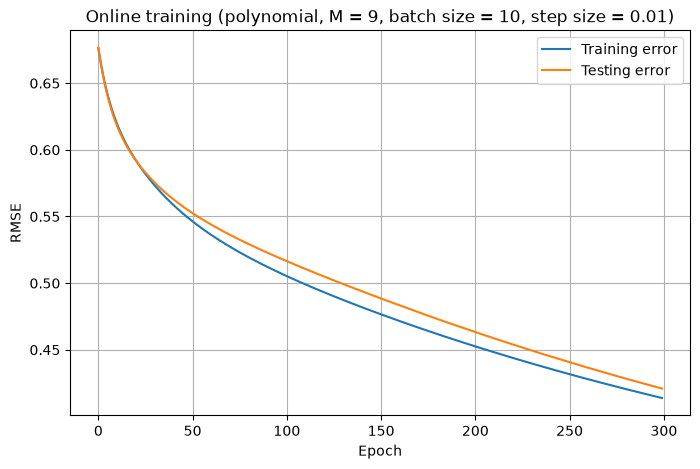

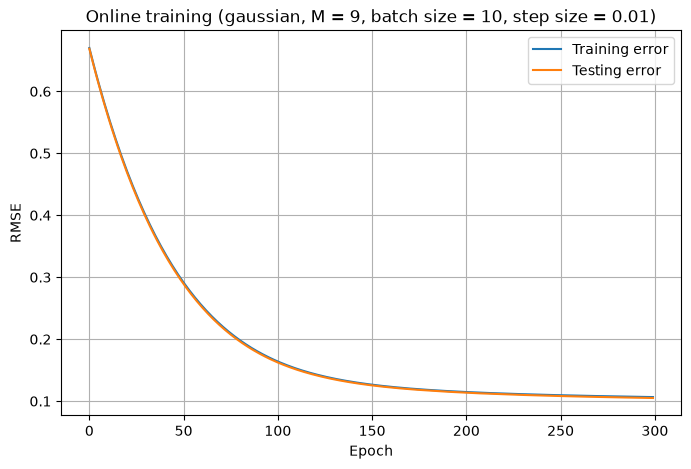

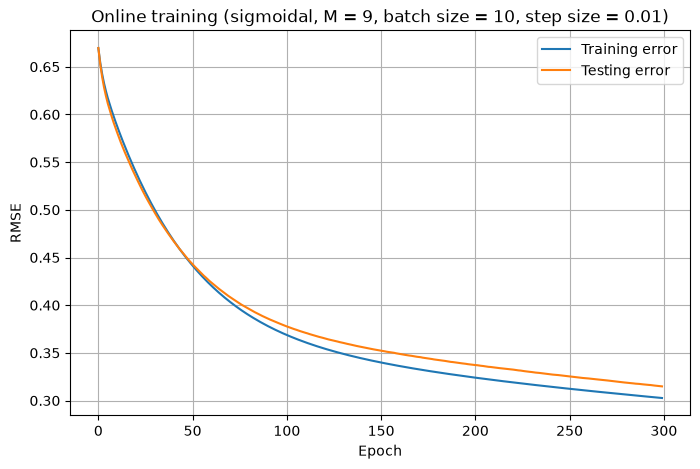

Comparison of online training (SGD) with the closed form solution (Part-3a data):
polynomial: SGD -> train RMSE = 0.4135, test RMSE = 0.4205 | closed form -> train RMSE = 0.0890, test RMSE = 0.0902
gaussian: SGD -> train RMSE = 0.1065, test RMSE = 0.1050 | closed form -> train RMSE = 0.0931, test RMSE = 0.0953
sigmoidal: SGD -> train RMSE = 0.3025, test RMSE = 0.3147 | closed form -> train RMSE = 0.0887, test RMSE = 0.0923


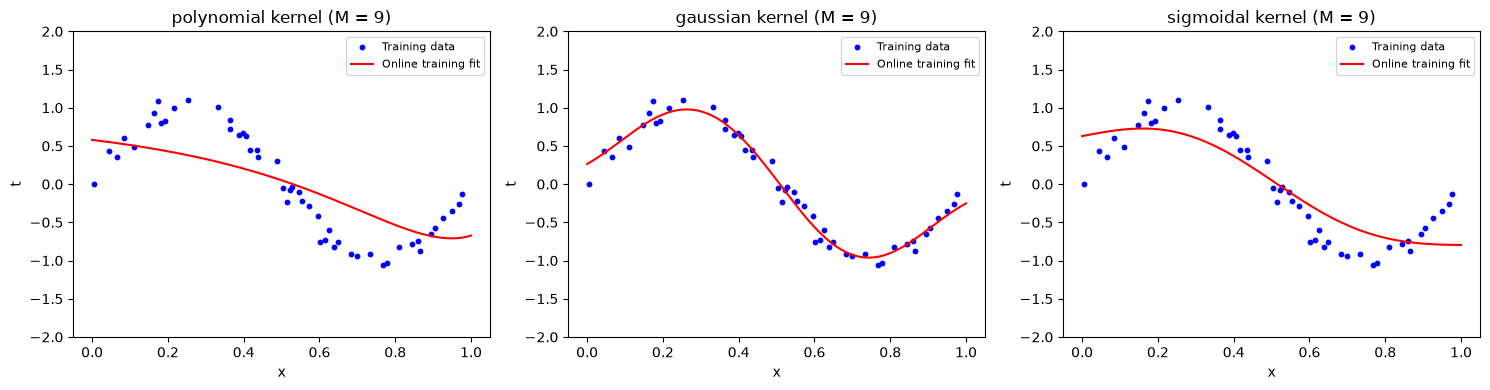

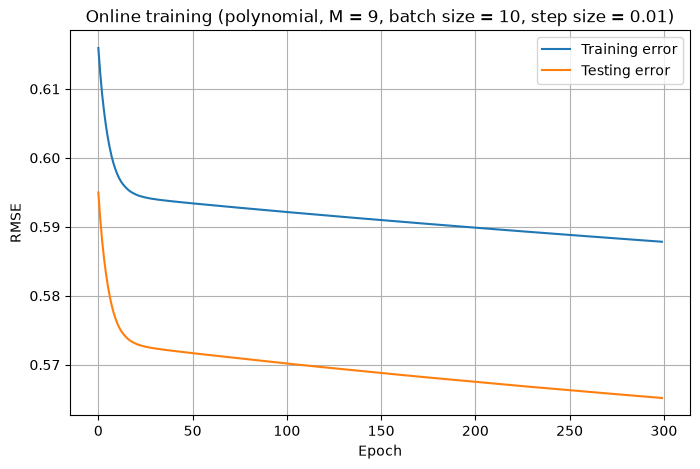

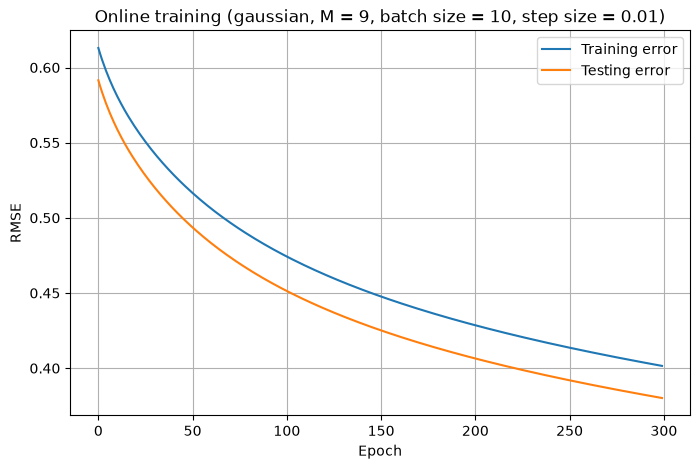

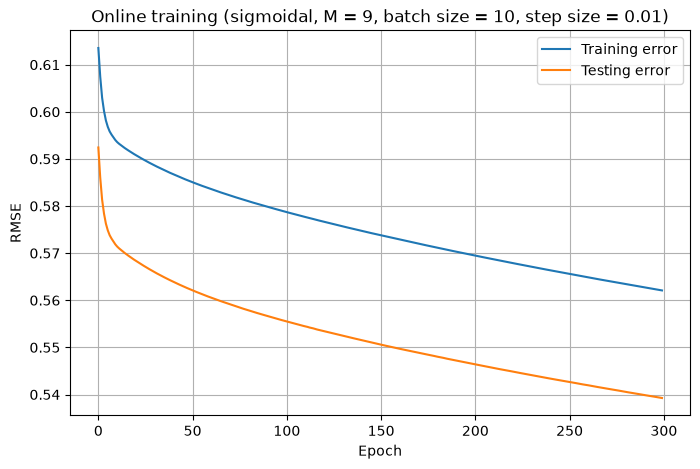

Comparison of online training (SGD) with the closed form solution (Part-3b data):
polynomial: SGD -> train RMSE = 0.5878, test RMSE = 0.5652 | closed form -> train RMSE = 0.2009, test RMSE = 0.2022
gaussian: SGD -> train RMSE = 0.4013, test RMSE = 0.3800 | closed form -> train RMSE = 0.2338, test RMSE = 0.2095
sigmoidal: SGD -> train RMSE = 0.5620, test RMSE = 0.5392 | closed form -> train RMSE = 0.1798, test RMSE = 0.1769


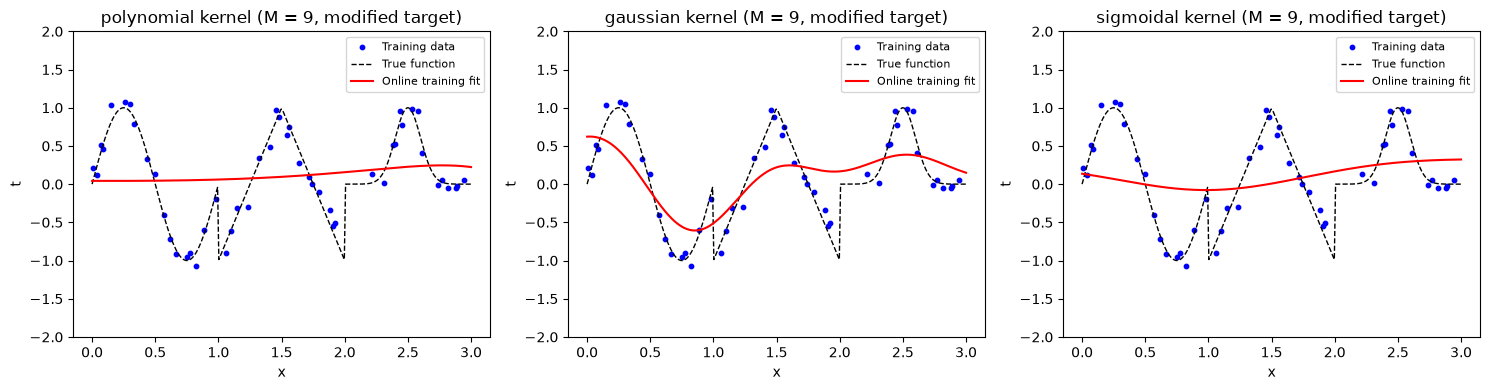

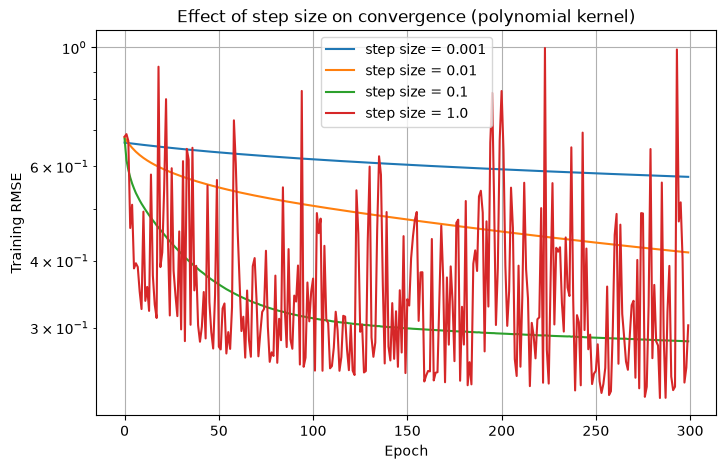

Effect of step size: a very small step size converges slowly, a moderate step size converges quickly and stably to the least squares solution, and a large step size makes the updates overshoot the minimum so that the error oscillates and eventually diverges.


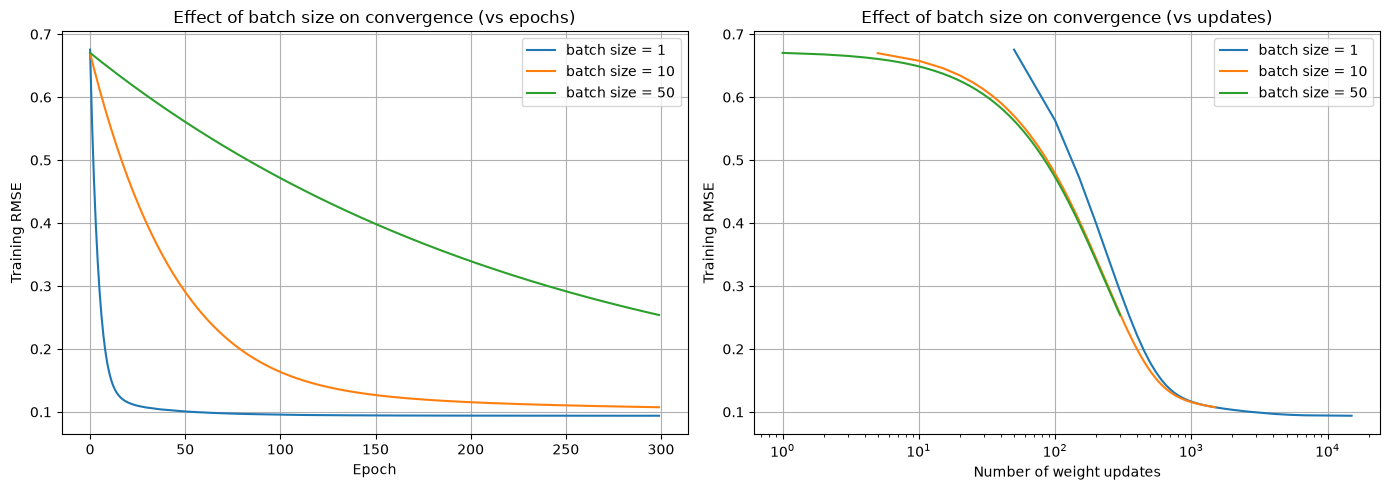

Effect of batch size: with a small batch size there are more weight updates per epoch, so the error decreases faster per epoch but the updates are noisier; with a large batch size each update is smoother but there are fewer updates per epoch, so convergence per epoch is slower. When compared on the number of weight updates, the small batch size needs fewer updates to converge.


In [4]:
#Understanding online training
########################################
#Repeat 3(a) and 3(b) using stochastic gradient descent for weight update ( plot required results )
########################################

#Helper to transform the data with the specified kernel (same as in Part-3)
def kernel_design_matrix(x, kernelType, M, x_ref):
    N = len(x)
    x_min, x_max = x_ref.min(), x_ref.max()
    span = x_max - x_min
    if kernelType == 'polynomial':
        u = (x - x_min) / span
        return np.vstack([u ** m for m in range(M + 1)]).T
    if kernelType == 'gaussian':
        if M == 0:
            return np.ones((N, 1))
        centers = np.linspace(x_min, x_max, M)
        sigma = span / M
        return np.hstack((np.ones((N, 1)), np.exp(-((x.reshape(-1, 1) - centers.reshape(1, -1)) ** 2) / (2 * sigma ** 2))))
    if kernelType == 'sigmoidal':
        if M == 0:
            return np.ones((N, 1))
        centers = np.linspace(x_min, x_max, M)
        s = span / M
        return np.hstack((np.ones((N, 1)), 1 / (1 + np.exp(-(x.reshape(-1, 1) - centers.reshape(1, -1)) / s))))
    raise ValueError("Unknown kernel type: " + str(kernelType))

def ErrorPred(w_est,X_train,Y_train,X_test,Y_test,kernelType): #(estimated weight, training data, training targets, testing data, testing targets, type of the kernel )
    #kernelType : {Polynomial,Gaussian,Sigmoid}
    #Obtain the target estimates using the current weights
    Y_tr_pred, Y_te_pred = OnlinePred(w_est, X_train, X_test, kernelType)

    #Compute and return the train and test errors
    TrainError = np.sqrt(np.mean((Y_train - Y_tr_pred) ** 2))
    TestError = np.sqrt(np.mean((Y_test - Y_te_pred) ** 2))
    return TrainError, TestError


def OnlineTraining(X_train,Y_train,X_test, Y_test, kernelType,M,Epochs,BatchSize,stepSize,plot_curves=True): #(training data, training targets, testing data, testing targets, tupe of the kernel, order of the mode, Number of epochs, Batch size, Step size)
    #kernelType : {Polynomial,Gaussian,Sigmoid}
    #Initialize the weights
    weights = np.random.normal(0, 0.01, M + 1)

    #Initialize the necessary variables
    tr_errors, te_errors = [], []
    N = len(X_train)
    #Iterate through epochs
    epochs = range(Epochs)
    for epoch in epochs:
        #Compute the train and test errors using the current weights
        tr_err, te_err = ErrorPred(weights, X_train, Y_train, X_test, Y_test, kernelType)
        #Store training and testing errors for plotting
        tr_errors.append(tr_err)
        te_errors.append(te_err)

        #Shuffle the data
        shuffle_idx = np.random.permutation(N)
        X_shuffled, Y_shuffled = X_train[shuffle_idx], Y_train[shuffle_idx]

        #Iterate through the batches
        batches = N // BatchSize
        for batch in range(batches):
            #Initialize the necessary variables
            grad_mean = np.zeros(M + 1)
            #Get a batch of data
            start = batch * BatchSize
            data_b = X_shuffled[start:start + BatchSize]
            targets_b = Y_shuffled[start:start + BatchSize]

            #Iterate through the data points of obtained batch
            for n in range(len(data_b)):
                #Obtain kernel representation
                X_tr = kernel_design_matrix(data_b[n:n + 1], kernelType, M, X_train).ravel()

                #Compute the gradient of weight's
                #For the squared error e = (1/2)*(t - w^T phi)^2, the gradient is -(t - w^T phi) * phi
                grad = -(targets_b[n] - X_tr @ weights) * X_tr

                #Compute the running mean of the weights gradients for the batch update
                grad_mean += grad

            #Update the weights using mean gradient, consider using reasonable stepSize
            weights = weights - stepSize * grad_mean / BatchSize

    #Plot training and testing error across the epochs
    if plot_curves:
        plt.figure(figsize=(8, 5))
        plt.plot(range(Epochs), tr_errors, label='Training error')
        plt.plot(range(Epochs), te_errors, label='Testing error')
        plt.xlabel('Epoch')
        plt.ylabel('RMSE')
        plt.title(f'Online training ({kernelType}, M = {M}, batch size = {BatchSize}, step size = {stepSize})')
        plt.legend()
        plt.grid(True)
        plt.show()

    #Return the estimated weights along with the error curves
    return weights, tr_errors, te_errors

def OnlinePred(w_est,X_train,X_test,kernelType): #(estimated weights, training data, testing data, type of the kernel )
    #kernelType : {Polynomial,Gaussian,Sigmoid}
    #Initialize the required variables
    M = len(w_est) - 1

    #Obtain kernel representations
    X_tr = kernel_design_matrix(X_train, kernelType, M, X_train)
    X_te = kernel_design_matrix(X_test, kernelType, M, X_train)

    #Compute and return the training and testing target estimates
    Y_tr_error = X_tr @ w_est
    Y_te_error = X_te @ w_est
    return Y_tr_error,Y_te_error

def OnlinePred_Error(w_est,X_train,Y_train,X_test,Y_test,kernelType): #(estimated weights, training data, training targets, testing data, testing targets, type of the kernel )
    #kernelType : {Polynomial,Gaussian,Sigmoid}
    #Initialize the required variables

    #Obtain kernel representations
    Y_tr_pred, Y_te_pred = OnlinePred(w_est, X_train, X_test, kernelType)

    #Compute and return the training and testing errors
    Y_tr_error = np.sqrt(np.mean((Y_train - Y_tr_pred) ** 2))
    Y_te_error = np.sqrt(np.mean((Y_test - Y_te_pred) ** 2))
    return Y_tr_error,Y_te_error


##################################################
#Repeat 3a with online training
##################################################
#Data: 100 points of the sinusoid, even samples for training and odd for testing (generated in Part-3)
M_online = 9
Epochs = 300
BatchSize = 10
stepSize = 0.01

results_3a = {}
for kt in kernel_types:
    w_on, tr_err_curve, te_err_curve = OnlineTraining(X_train, Y_train, X_test, Y_test, kt, M_online, Epochs, BatchSize, stepSize)
    results_3a[kt] = (w_on, tr_err_curve, te_err_curve)

#Compare the SGD solutions with the closed form solutions of Part-3
print("Comparison of online training (SGD) with the closed form solution (Part-3a data):")
for kt in kernel_types:
    w_on = results_3a[kt][0]
    tr_err_sgd, te_err_sgd = OnlinePred_Error(w_on, X_train, Y_train, X_test, Y_test, kt)
    w_closed = KernelRegressionFit(X_train, Y_train, kt, M_online, lamda=0)
    tr_err_cf, te_err_cf = KernelRegressionPred_Error(w_closed, X_train, Y_train, X_test, Y_test, kt)
    print(f"{kt}: SGD -> train RMSE = {tr_err_sgd:.4f}, test RMSE = {te_err_sgd:.4f} | closed form -> train RMSE = {tr_err_cf:.4f}, test RMSE = {te_err_cf:.4f}")

#Plot the final fits obtained with online training
x_dense_p4 = np.linspace(0, 1, 300)
plt.figure(figsize=(15, 4))
for i, kt in enumerate(kernel_types):
    w_on = results_3a[kt][0]
    dense_pred = OnlinePred(w_on, X_train, x_dense_p4, kt)[1]
    plt.subplot(1, 3, i + 1)
    plt.scatter(X_train, Y_train, s=10, color='blue', label='Training data')
    plt.plot(x_dense_p4, dense_pred, color='red', label='Online training fit')
    plt.title(f'{kt} kernel (M = {M_online})')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.ylim(-2, 2)
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

##################################################
#Repeat 3b with online training
##################################################
#Data: piecewise target (sinusoid, triangle, Gaussian bump) generated in Part-3
results_3b = {}
for kt in kernel_types:
    w_on, tr_err_curve, te_err_curve = OnlineTraining(X_train_mod, Y_train_mod, X_test_mod, Y_test_mod, kt, M_online, Epochs, BatchSize, stepSize)
    results_3b[kt] = (w_on, tr_err_curve, te_err_curve)

print("Comparison of online training (SGD) with the closed form solution (Part-3b data):")
for kt in kernel_types:
    w_on = results_3b[kt][0]
    tr_err_sgd, te_err_sgd = OnlinePred_Error(w_on, X_train_mod, Y_train_mod, X_test_mod, Y_test_mod, kt)
    w_closed = KernelRegressionFit(X_train_mod, Y_train_mod, kt, M_online, lamda=0)
    tr_err_cf, te_err_cf = KernelRegressionPred_Error(w_closed, X_train_mod, Y_train_mod, X_test_mod, Y_test_mod, kt)
    print(f"{kt}: SGD -> train RMSE = {tr_err_sgd:.4f}, test RMSE = {te_err_sgd:.4f} | closed form -> train RMSE = {tr_err_cf:.4f}, test RMSE = {te_err_cf:.4f}")

x_dense_p4b = np.linspace(0, 3, 300)
plt.figure(figsize=(15, 4))
for i, kt in enumerate(kernel_types):
    w_on = results_3b[kt][0]
    dense_pred = OnlinePred(w_on, X_train_mod, x_dense_p4b, kt)[1]
    plt.subplot(1, 3, i + 1)
    plt.scatter(X_train_mod, Y_train_mod, s=10, color='blue', label='Training data')
    plt.plot(x_dense_p4b, target_function_modified(x_dense_p4b), color='black', linestyle='--', linewidth=1, label='True function')
    plt.plot(x_dense_p4b, dense_pred, color='red', label='Online training fit')
    plt.title(f'{kt} kernel (M = {M_online}, modified target)')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.ylim(-2, 2)
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

########################################
#Study the effect of stepSize on the convergence of weights ( plot required results )
########################################
step_sizes = [0.001, 0.01, 0.1, 1.0]
plt.figure(figsize=(8, 5))
for ss in step_sizes:
    w_ss, tr_err_ss, te_err_ss = OnlineTraining(X_train, Y_train, X_test, Y_test, 'polynomial', M_online, Epochs, BatchSize, ss, plot_curves=False)
    tr_err_plot = np.clip(np.nan_to_num(np.array(tr_err_ss), nan=1e4, posinf=1e4), 1e-4, 1e4)
    plt.plot(range(Epochs), tr_err_plot, label=f'step size = {ss}')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Training RMSE')
plt.title('Effect of step size on convergence (polynomial kernel)')
plt.legend()
plt.grid(True)
plt.show()
print("Effect of step size: a very small step size converges slowly, a moderate step size converges quickly and stably to the least squares solution, and a large step size makes the updates overshoot the minimum so that the error oscillates and eventually diverges.")

########################################
#Study the effect of batchsize on the speed of convergence ( plot required results )
########################################
batch_sizes = [1, 10, 50]
batch_results = {}
for bs in batch_sizes:
    w_bs, tr_err_bs, te_err_bs = OnlineTraining(X_train, Y_train, X_test, Y_test, 'gaussian', M_online, Epochs, BatchSize=bs, stepSize=0.01, plot_curves=False)
    batch_results[bs] = tr_err_bs

plt.figure(figsize=(14, 5))
plt.subplot(121)
for bs in batch_sizes:
    plt.plot(range(Epochs), batch_results[bs], label=f'batch size = {bs}')
plt.xlabel('Epoch')
plt.ylabel('Training RMSE')
plt.title('Effect of batch size on convergence (vs epochs)')
plt.legend()
plt.grid(True)
plt.subplot(122)
for bs in batch_sizes:
    updates = np.arange(1, Epochs + 1) * (len(X_train) // bs)
    plt.plot(updates, batch_results[bs], label=f'batch size = {bs}')
plt.xscale('log')
plt.xlabel('Number of weight updates')
plt.ylabel('Training RMSE')
plt.title('Effect of batch size on convergence (vs updates)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Effect of batch size: with a small batch size there are more weight updates per epoch, so the error decreases faster per epoch but the updates are noisier; with a large batch size each update is smoother but there are fewer updates per epoch, so convergence per epoch is slower. When compared on the number of weight updates, the small batch size needs fewer updates to converge.")

<b> Report your observations </b>

1. Online training (stochastic gradient descent) converges to a solution very close to the closed form pseudo-inverse solution for all three kernels; the training and testing RMSE curves decrease with the number of epochs and flatten out once the weights converge.

2. The step size eta controls the convergence: a small step size (0.001) converges slowly, a moderate step size (0.01) converges quickly and stably, while a large step size (0.1 and above) makes the updates overshoot the minimum of the error surface so the error oscillates and eventually diverges.

3. The batch size trades off noise and speed of convergence: with a small batch size there are more weight updates per epoch, so convergence per epoch is faster but noisier; with a large batch size the updates are smoother but fewer per epoch, so convergence per epoch is slower. When compared on the number of weight updates, the small batch size needs fewer updates to reach the same error.

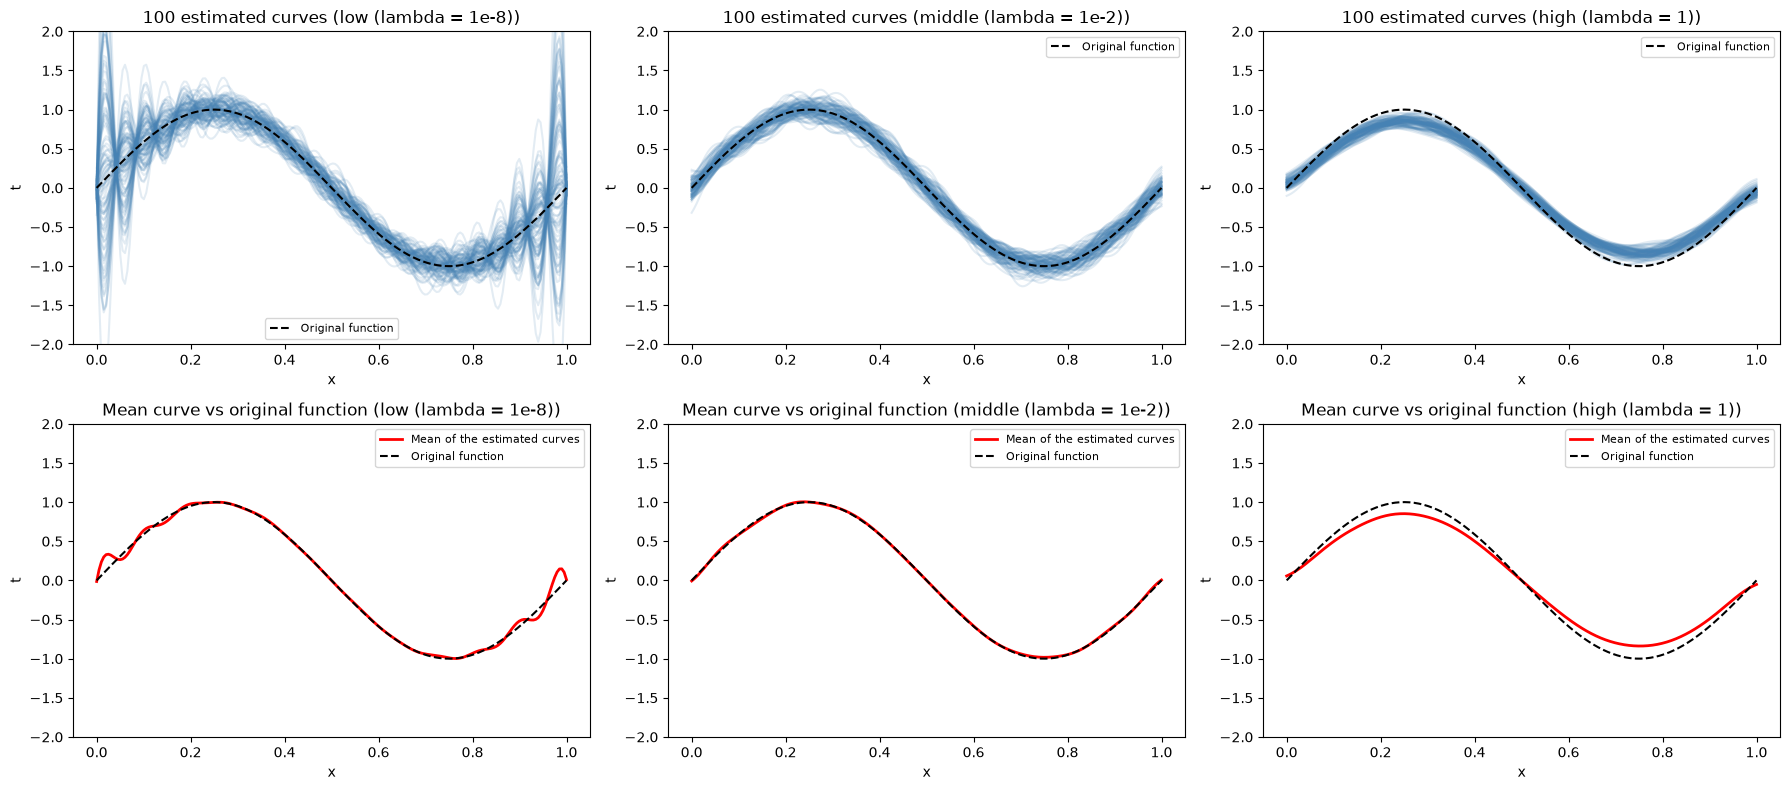

In [5]:
#Understanding the bias-variance trade-off
########################################
#Generate 100 data sets of noisy sinusoidal data
########################################
np.random.seed(6)
L = 100   #number of datasets
N = 25    #number of data points in each dataset
#Use the same x grid for all datasets, with a different noise realization for each dataset
x_grid = np.linspace(0, 1, N)
noise_all = np.random.normal(0, 0.1, (L, N))
t_all = np.sin(2 * np.pi * x_grid)[None, :] + noise_all

########################################
#Use regularized least squares to estimate w
########################################
#Model: M = 25th order linear regression model consisting of 24 Gaussian basis functions and one bias parameter
M_bv = 24   #number of Gaussian basis functions (plus one bias parameter)

#Centers and width of the Gaussian basis functions
centers_bv = np.linspace(0, 1, M_bv)
sigma_bv = 1 / M_bv

def design_matrix_bv(x):
    #Gaussian basis functions plus a bias term
    return np.hstack((np.ones((len(x), 1)), np.exp(-((x.reshape(-1, 1) - centers_bv.reshape(1, -1)) ** 2) / (2 * sigma_bv ** 2))))

def regularized_ls_fit(x, t, lamda):
    #Regularized least squares solution (the bias is not regularized)
    Phi = design_matrix_bv(x)
    P = lamda * np.eye(Phi.shape[1])
    P[0, 0] = 0
    return np.linalg.pinv(Phi.T @ Phi + P) @ Phi.T @ t

########################################
#Illustrate the concept of Bias-Variance trade off
########################################
#1. Chose three different regularization coefficeints (low,middle and high)
#2. For every regularization coefficient, produce two plots: one displaying 100 estimated curves, and the other showing the mean of the estimated curves alongside the original function.
#3. For three regularization coefficients, you should have a total of six plots, meaning two plots for each regularization.
#4. Using the six plots above, describe the bias-variance trade-off.
lambdas_bv = {'low (lambda = 1e-8)': 1e-8, 'middle (lambda = 1e-2)': 1e-2, 'high (lambda = 1)': 1}

x_dense_bv = np.linspace(0, 1, 200)
Phi_dense_bv = design_matrix_bv(x_dense_bv)
fig_bv, axes_bv = plt.subplots(2, 3, figsize=(18, 8))
for col, (name, lamda) in enumerate(lambdas_bv.items()):
    curves = []
    for l in range(L):
        w_l = regularized_ls_fit(x_grid, t_all[l], lamda)
        curves.append(Phi_dense_bv @ w_l)
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)

    #Plot the 100 estimated curves
    ax = axes_bv[0, col]
    for c in curves:
        ax.plot(x_dense_bv, c, color='steelblue', alpha=0.15)
    ax.plot(x_dense_bv, np.sin(2 * np.pi * x_dense_bv), 'k--', linewidth=1.5, label='Original function')
    ax.set_title(f'100 estimated curves ({name})')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=8)

    #Plot the mean of the estimated curves alongside the original function
    ax = axes_bv[1, col]
    ax.plot(x_dense_bv, mean_curve, color='red', linewidth=2, label='Mean of the estimated curves')
    ax.plot(x_dense_bv, np.sin(2 * np.pi * x_dense_bv), 'k--', linewidth=1.5, label='Original function')
    ax.set_title(f'Mean curve vs original function ({name})')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

<b> Report your observations </b>

1. Low regularization (lambda = 1e-8): the 100 estimated curves pass through almost every noisy data point of their own dataset and vary wildly from dataset to dataset - the variance is very large while the bias (deviation of the mean curve from the true function) is small. This is overfitting.

2. Middle regularization (lambda = 1e-2): the estimated curves are much smoother and closer to each other; both the bias and the variance are moderate and the mean curve still follows the sinusoid closely.

3. High regularization (lambda = 1): all the curves are strongly shrunk towards a nearly straight line - the variance is very small but the mean fit deviates substantially from the true function, i.e., the bias is large. This is underfitting. Bias-variance trade-off: increasing lambda reduces the variance of the model at the cost of an increased bias, and a good model balances the two.

Posterior mean (first 5 weights): [ 0.10158494 -0.20400609  0.14197406  0.33402012  0.20732852]


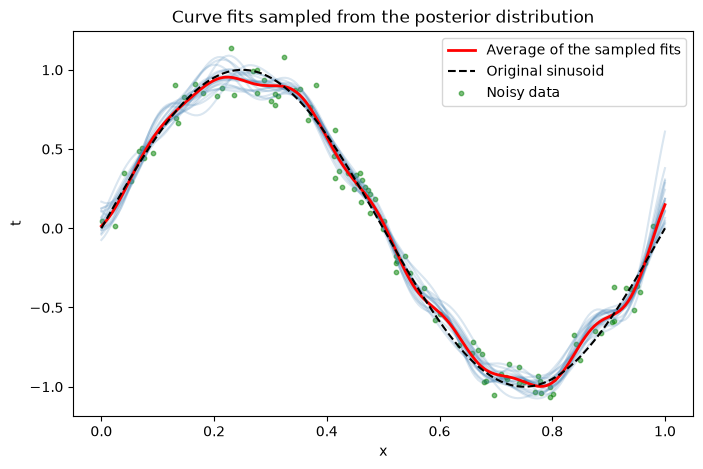

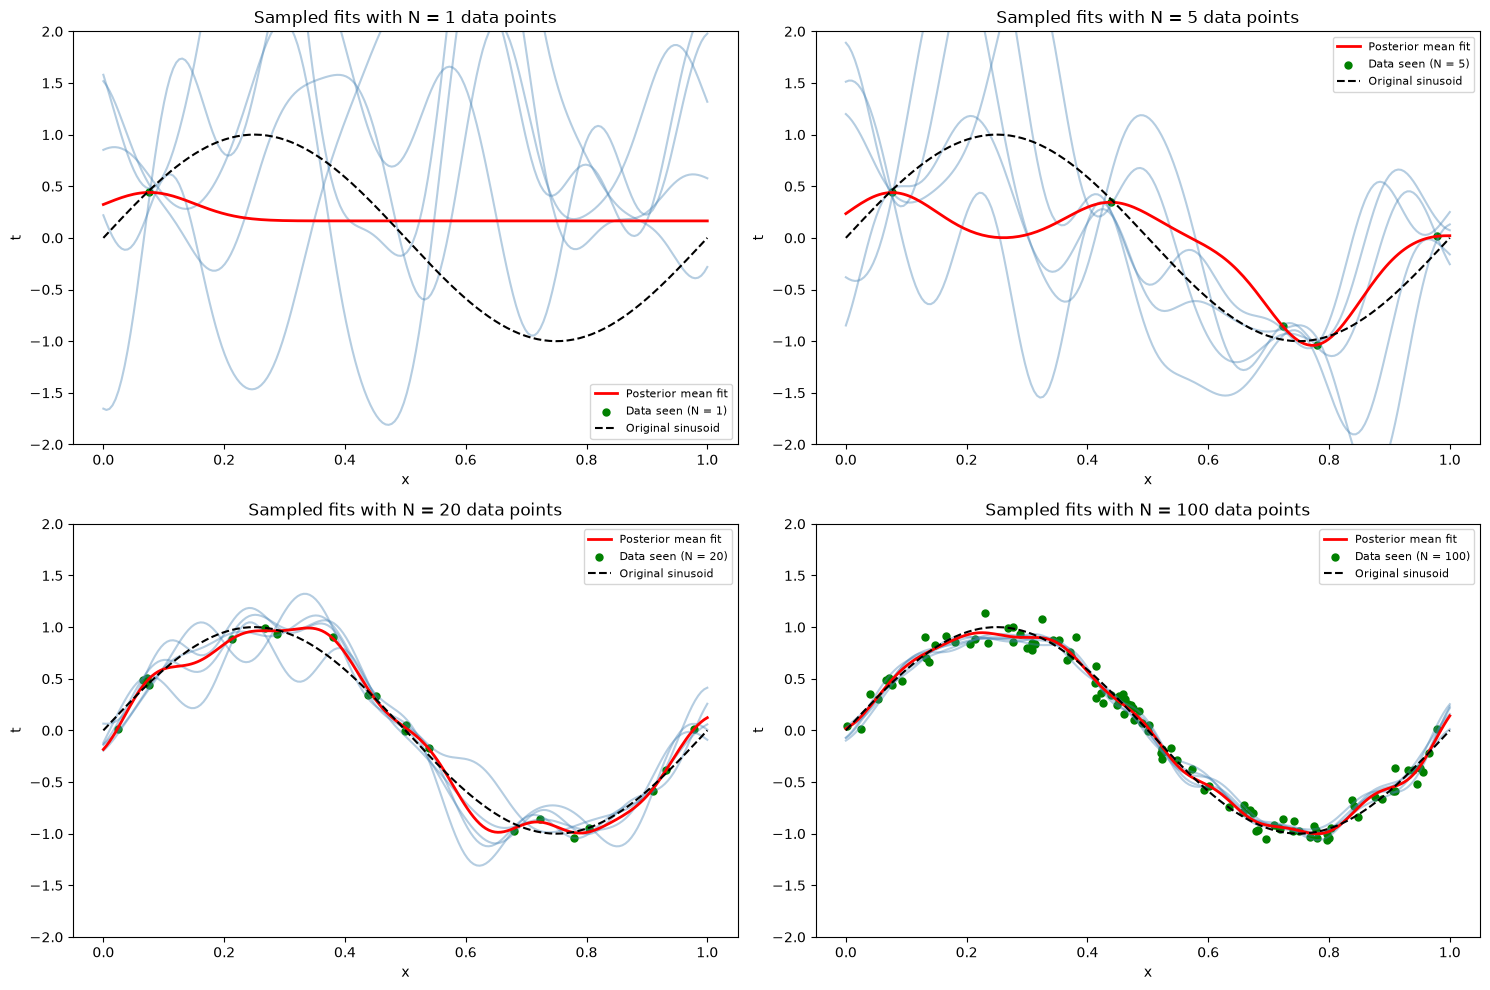

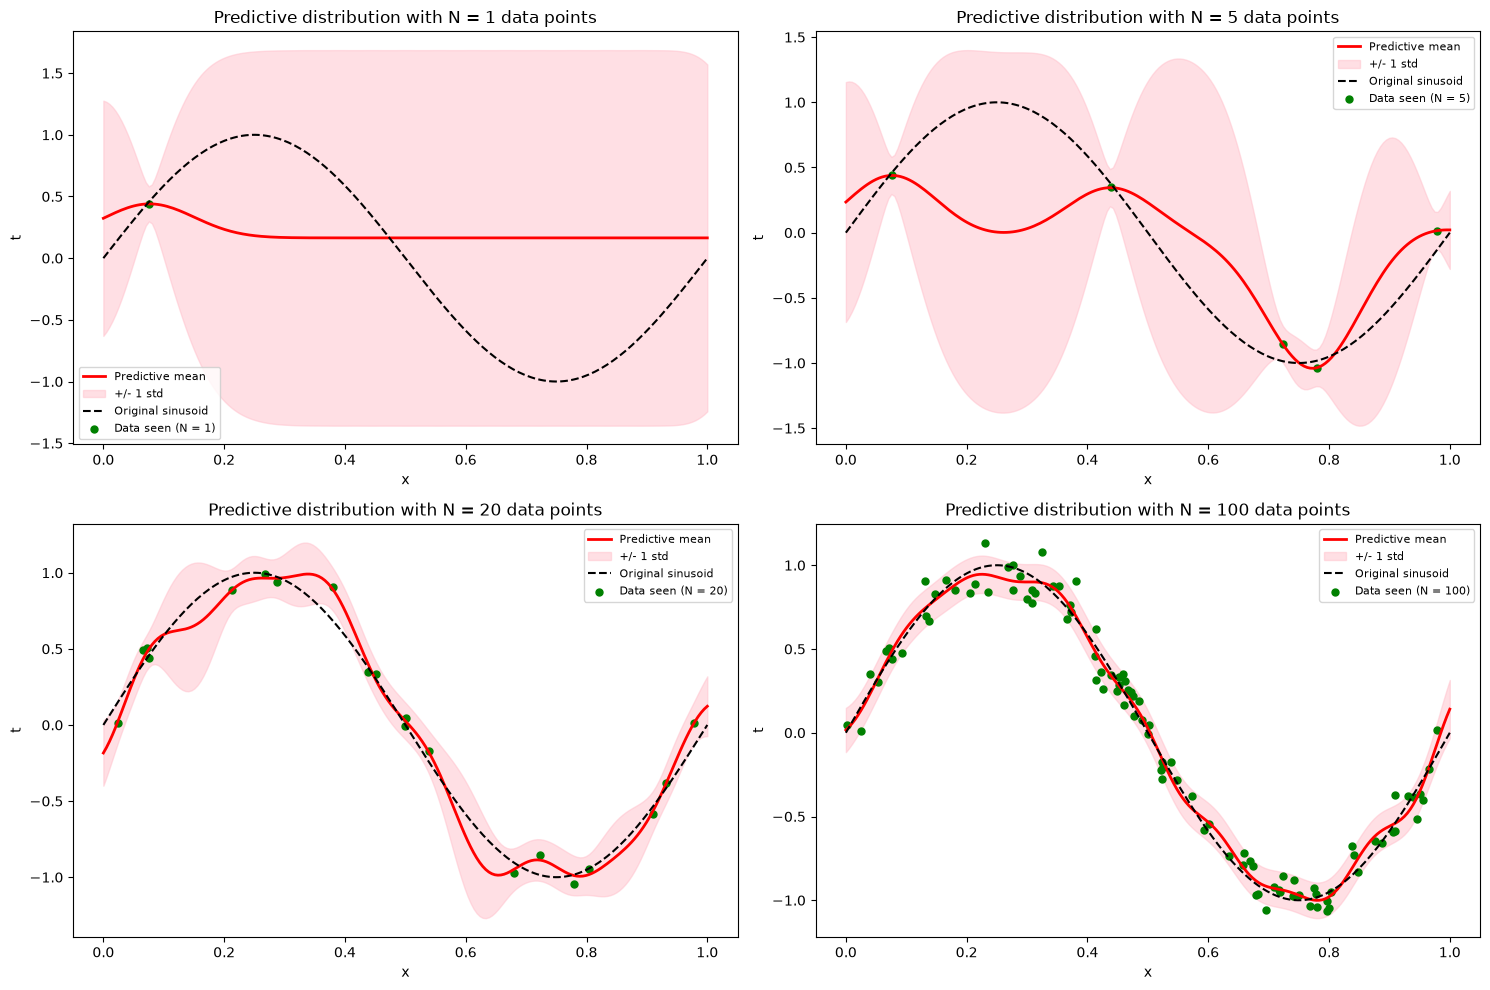

In [6]:
#Understanding MAP estimate
########################################
#Generate 100 data sets of noisy sinusoidal data
########################################
np.random.seed(7)
N_map = 100
x_map = np.random.uniform(0, 1, N_map)
noise_map = np.random.normal(0, 0.1, N_map)
t_map = np.sin(2 * np.pi * x_map) + noise_map

#Model: 20th order linear regression model with Gaussian basis functions (19 basis functions + one bias parameter)
M_map = 19
centers_map = np.linspace(0, 1, M_map)
sigma_map = 1 / M_map

def design_matrix_map(x):
    #Gaussian basis functions plus a bias term
    return np.hstack((np.ones((len(x), 1)), np.exp(-((np.asarray(x).reshape(-1, 1) - centers_map.reshape(1, -1)) ** 2) / (2 * sigma_map ** 2))))

Phi_map = design_matrix_map(x_map)

########################################
#Update the statistics of posterior density
########################################
#Initialie the parameters for standard normal prior
m0 = np.zeros(M_map + 1)      #mean of the standard normal prior
S0 = np.eye(M_map + 1)        #covariance of the standard normal prior
beta_map = 1 / 0.1 ** 2       #precision of the noise (e ~ N(0, 0.1))

#Iterate through the data points and update the stats of posterior density
#Sequential Bayesian update:
#   S_n^(-1) = S_(n-1)^(-1) + beta * phi_n phi_n^T
#   b_n = b_(n-1) + beta * t_n * phi_n   (with b_n = S_n^(-1) m_n)
#   m_n = S_n b_n
S_post = S0.copy()
m_post = m0.copy()
S_post_inv = np.linalg.inv(S0)
b_post = S_post_inv @ m0
posterior_snapshots = {}
N_snapshots = [1, 5, 20, 100]   #number of data points seen for the predictive distribution analysis
for n in range(N_map):
    phi_n = Phi_map[n].reshape(-1, 1)
    t_n = t_map[n]
    #Update the inverse covariance (precision) and the mean of the posterior
    S_post_inv = S_post_inv + beta_map * (phi_n @ phi_n.T)
    b_post = b_post + beta_map * t_n * phi_n.ravel()
    S_post = np.linalg.inv(S_post_inv)
    m_post = S_post @ b_post
    #Store the posterior statistics when partial data points are seen
    if (n + 1) in N_snapshots:
        posterior_snapshots[n + 1] = (m_post.copy(), S_post.copy())

print("Posterior mean (first 5 weights):", m_post[:5])

########################################
#Sample weight vector from posterior distribution. Estimate the curve, repeat the procedure for 100 times and get the avg fit
########################################
x_dense_map = np.linspace(0, 1, 200)
Phi_dense_map = design_matrix_map(x_dense_map)
n_samples = 100
sampled_curves = []
for s in range(n_samples):
    w_sample = np.random.multivariate_normal(m_post, S_post)
    sampled_curves.append(Phi_dense_map @ w_sample)
sampled_curves = np.array(sampled_curves)
avg_fit = sampled_curves.mean(axis=0)

plt.figure(figsize=(8, 5))
for c in sampled_curves[:20]:
    plt.plot(x_dense_map, c, color='steelblue', alpha=0.2)
plt.plot(x_dense_map, avg_fit, color='red', linewidth=2, label='Average of the sampled fits')
plt.plot(x_dense_map, np.sin(2 * np.pi * x_dense_map), 'k--', linewidth=1.5, label='Original sinusoid')
plt.scatter(x_map, t_map, s=10, color='green', alpha=0.5, label='Noisy data')
plt.title('Curve fits sampled from the posterior distribution')
plt.xlabel('x')
plt.ylabel('t')
plt.legend()
plt.show()

########################################
#Predictive distribution analysis
########################################
#Predictive distribution analysis through sampling
#Iterate through data points and sample weight vectors when partial data points are seen, and plot the curves
plt.figure(figsize=(15, 10))
for i, n_p in enumerate(N_snapshots):
    m_p, S_p = posterior_snapshots[n_p]
    plt.subplot(2, 2, i + 1)
    for s in range(5):
        w_s = np.random.multivariate_normal(m_p, S_p)
        plt.plot(x_dense_map, Phi_dense_map @ w_s, color='steelblue', alpha=0.4)
    plt.plot(x_dense_map, Phi_dense_map @ m_p, color='red', linewidth=2, label='Posterior mean fit')
    plt.scatter(x_map[:n_p], t_map[:n_p], color='green', s=25, label=f'Data seen (N = {n_p})')
    plt.plot(x_dense_map, np.sin(2 * np.pi * x_dense_map), 'k--', linewidth=1.5, label='Original sinusoid')
    plt.title(f'Sampled fits with N = {n_p} data points')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.ylim(-2, 2)
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

#Predictive distribution analysis through variance
#Iterate through data points and obtain necessary plots as discussed in the class
#Predictive distribution: p(t | x, X, t) = N(m_N^T phi(x), sigma^2(x)) with sigma^2(x) = 1/beta + phi(x)^T S_N phi(x)
plt.figure(figsize=(15, 10))
for i, n_v in enumerate(N_snapshots):
    m_v, S_v = posterior_snapshots[n_v]
    mean_curve_v = Phi_dense_map @ m_v
    pred_var = 1 / beta_map + np.sum((Phi_dense_map @ S_v) * Phi_dense_map, axis=1)
    pred_std = np.sqrt(pred_var)
    plt.subplot(2, 2, i + 1)
    plt.plot(x_dense_map, mean_curve_v, color='red', linewidth=2, label='Predictive mean')
    plt.fill_between(x_dense_map, mean_curve_v - pred_std, mean_curve_v + pred_std, color='pink', alpha=0.5, label='+/- 1 std')
    plt.plot(x_dense_map, np.sin(2 * np.pi * x_dense_map), 'k--', linewidth=1.5, label='Original sinusoid')
    plt.scatter(x_map[:n_v], t_map[:n_v], color='green', s=25, label=f'Data seen (N = {n_v})')
    plt.title(f'Predictive distribution with N = {n_v} data points')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

<b> Report your observations </b>

1. The sequential Bayesian updates converge to a posterior that concentrates around the true sinusoid: as more data points are seen, the posterior mean fit approaches the original function and the posterior uncertainty shrinks.

2. The curve fits sampled from the posterior scatter around the true sinusoid and their average is very close to the posterior mean fit and to the original sinusoid.

3. The predictive distribution is wide (high uncertainty) when only a few data points are seen, and becomes narrow around the data as the number of training points grows; with N = 100 points the predictive mean matches the original sinusoid and the uncertainty band is small near the observed data.